In [2]:
# Imported Libraries

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA, TruncatedSVD
import matplotlib.patches as mpatches
import time

# Classifier Libraries
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import collections


# Other Libraries
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from imblearn.pipeline import make_pipeline as imbalanced_make_pipeline
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import NearMiss
from imblearn.metrics import classification_report_imbalanced
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, accuracy_score, classification_report
from collections import Counter
from sklearn.model_selection import KFold, StratifiedKFold
import warnings
warnings.filterwarnings("ignore")


df = pd.read_csv('data/creditcard.csv')
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [4]:
# Good No Null Values!
df.isnull().sum().max()

0

In [5]:
df.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

In [6]:
# The classes are heavily skewed I need to solve this issue later.
print('No Frauds', round(df['Class'].value_counts()[0]/len(df) * 100,2), '% of the dataset')
print('Frauds', round(df['Class'].value_counts()[1]/len(df) * 100,2), '% of the dataset')

No Frauds 99.83 % of the dataset
Frauds 0.17 % of the dataset


Notice how imbalanced is our original dataset! Most of the transactions are non-fraud. If I use this dataframe as the base for our predictive models and analysis I might get a lot of errors and our algorithms will probably overfit since it will "assume" that most transactions are not fraud. But I don't want our model to assume, I want our model to detect patterns that give signs of fraud!

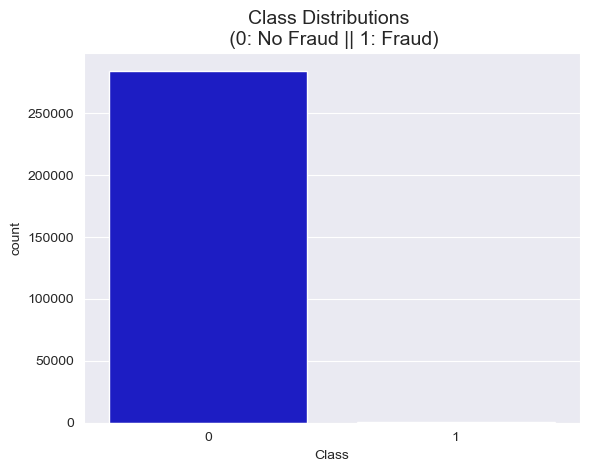

In [8]:
colors = ["#0101DF", "#DF0101"]

sns.countplot(x='Class', data=df, palette=colors)
plt.title('Class Distributions \n (0: No Fraud || 1: Fraud)', fontsize=14)
plt.show()

By seeing the distributions we can have an idea how skewed are these features, we can also see further distributions of the other features. There are techniques that can help the distributions be less skewed which will be implemented in this notebook in the future.

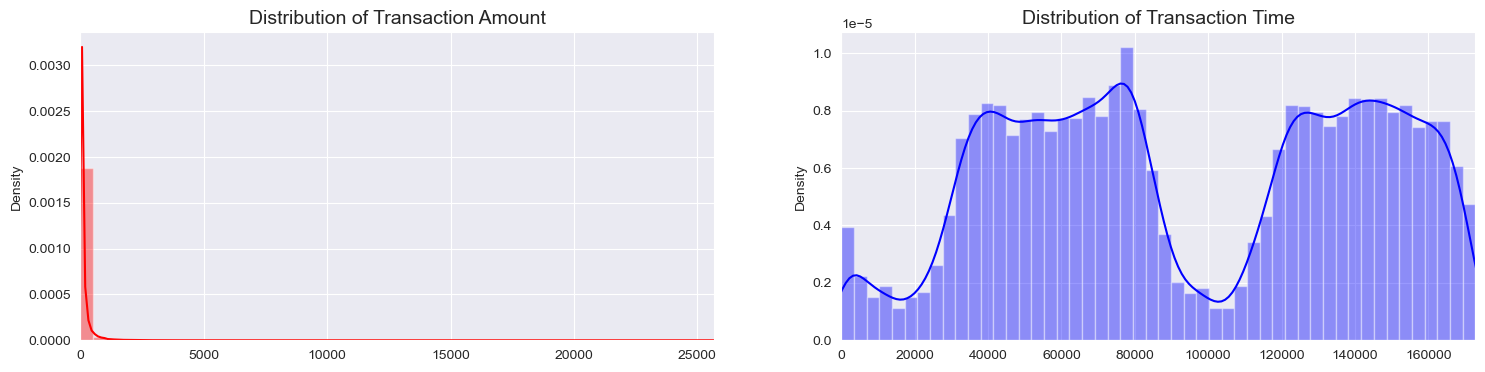

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(18,4))

amount_val = df['Amount'].values
time_val = df['Time'].values

sns.distplot(amount_val, ax=ax[0], color='r')
ax[0].set_title('Distribution of Transaction Amount', fontsize=14)
ax[0].set_xlim([min(amount_val), max(amount_val)])

sns.distplot(time_val, ax=ax[1], color='b')
ax[1].set_title('Distribution of Transaction Time', fontsize=14)
ax[1].set_xlim([min(time_val), max(time_val)])



plt.show()

## Scaling and Subsampling

In this phase, we scale the **Time** and **Amount** features so they are on the same scale as the other variables. Proper scaling ensures that no single feature dominates model training due to differences in magnitude.

We also create a **subsampled dataset** with an equal number of fraud and non-fraud transactions to help our models better learn patterns associated with fraudulent behavior.

---

### What is Subsampling?
Subsampling refers to creating a new dataset with a **50/50 ratio of fraud and non-fraud transactions**, meaning both classes are equally represented.

---

### Why Subsample?
The original dataset is **heavily imbalanced**, which can cause:
- **Overfitting**: Models may learn to always predict “non-fraud” since it dominates the data.
- **Misleading correlations**: Class imbalance can hide the true relationship between features and fraud outcomes.

Balancing the dataset allows the model to better understand what distinguishes fraud from non-fraud transactions.

---

### Summary
- **Time** and **Amount** are scaled to match other features.
- The dataset contains **492 fraud cases**, so we randomly select **492 non-fraud cases**.
- These are combined to form a **balanced subsample** used for model analysis and training.


In [10]:
# Since most of our data has already been scaled we should scale the columns that are left to scale (Amount and Time)
from sklearn.preprocessing import StandardScaler, RobustScaler

# RobustScaler is less prone to outliers.

std_scaler = StandardScaler()
rob_scaler = RobustScaler()

df['scaled_amount'] = rob_scaler.fit_transform(df['Amount'].values.reshape(-1,1))
df['scaled_time'] = rob_scaler.fit_transform(df['Time'].values.reshape(-1,1))

df.drop(['Time','Amount'], axis=1, inplace=True)

In [11]:
scaled_amount = df['scaled_amount']
scaled_time = df['scaled_time']

df.drop(['scaled_amount', 'scaled_time'], axis=1, inplace=True)
df.insert(0, 'scaled_amount', scaled_amount)
df.insert(1, 'scaled_time', scaled_time)

# Amount and Time are Scaled!

df.head()

,scaled_amount,scaled_time,V1,V2,V3,V4,V5,V6,V7,V8,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Class
0,1.783274,-0.994983,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,...,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0
1,-0.269825,-0.994983,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,...,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,0
2,4.983721,-0.994972,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,...,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,0
3,1.418291,-0.994972,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,...,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0
4,0.670579,-0.994960,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,...,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,0


## Splitting the Data (Original DataFrame)
Before proceeding with the Random UnderSampling technique we have to separate the orginal dataframe. Why? for testing purposes, remember although we are splitting the data when implementing Random UnderSampling or OverSampling techniques, we want to test our models on the original testing set not on the testing set created by either of these techniques. The main goal is to fit the model either with the dataframes that were undersample and oversample (in order for our models to detect the patterns), and test it on the original testing set.

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedShuffleSplit

print('No Frauds', round(df['Class'].value_counts()[0]/len(df) * 100,2), '% of the dataset')
print('Frauds', round(df['Class'].value_counts()[1]/len(df) * 100,2), '% of the dataset')

X = df.drop('Class', axis=1)
y = df['Class']

sss = StratifiedKFold(n_splits=5, random_state=None, shuffle=False)

for train_index, test_index in sss.split(X, y):
    print("Train:", train_index, "Test:", test_index)
    original_Xtrain, original_Xtest = X.iloc[train_index], X.iloc[test_index]
    original_ytrain, original_ytest = y.iloc[train_index], y.iloc[test_index]

# We already have X_train and y_train for undersample data thats why I am using original to distinguish and to not overwrite these variables.
# original_Xtrain, original_Xtest, original_ytrain, original_ytest = train_test_split(X, y, test_size=0.2, random_state=42)

# Check the Distribution of the labels


# Turn into an array
original_Xtrain = original_Xtrain.values
original_Xtest = original_Xtest.values
original_ytrain = original_ytrain.values
original_ytest = original_ytest.values

# See if both the train and test label distribution are similarly distributed
train_unique_label, train_counts_label = np.unique(original_ytrain, return_counts=True)
test_unique_label, test_counts_label = np.unique(original_ytest, return_counts=True)
print('-' * 100)

print('Label Distributions: \n')
print(train_counts_label/ len(original_ytrain))
print(test_counts_label/ len(original_ytest))

No Frauds 99.83 % of the dataset
Frauds 0.17 % of the dataset
Train: [ 30473  30496  31002 ... 284804 284805 284806] Test: [    0     1     2 ... 57017 57018 57019]
Train: [     0      1      2 ... 284804 284805 284806] Test: [ 30473  30496  31002 ... 113964 113965 113966]
Train: [     0      1      2 ... 284804 284805 284806] Test: [ 81609  82400  83053 ... 170946 170947 170948]
Train: [     0      1      2 ... 284804 284805 284806] Test: [150654 150660 150661 ... 227866 227867 227868]
Train: [     0      1      2 ... 227866 227867 227868] Test: [212516 212644 213092 ... 284804 284805 284806]
----------------------------------------------------------------------------------------------------
Label Distributions: 

[0.99827076 0.00172924]
[0.99827952 0.00172048]


## Random Under-Sampling

In this phase, we apply **Random Under-Sampling**, a technique that balances the dataset by **reducing the number of majority-class samples**. This helps prevent models from overfitting to the dominant non-fraud class.

---

### Steps
1. **Assess class imbalance**
   Use `value_counts()` on the target column to determine the number of fraud and non-fraud transactions.

2. **Balance the classes**
   Identify the number of fraud cases (Fraud = 1), then randomly select the same number of non-fraud cases to achieve a **50/50 class ratio**
   (e.g., 492 fraud and 492 non-fraud transactions).

3. **Create and shuffle the subsample**
   Combine the selected fraud and non-fraud cases and shuffle the data to ensure randomness and consistent model performance across runs.

---

### Note on Limitations
A key drawback of **Random Under-Sampling** is **information loss**. Reducing a large number of non-fraud transactions (e.g., from 284,315 down to 492) can cause models to miss important patterns, potentially reducing overall performance.

---

### Summary
- Random Under-Sampling balances the dataset by removing majority-class samples.
- Produces a **50/50 fraud vs non-fraud** subsample.
- Helps reduce overfitting but may sacrifice predictive power due to data loss.
`

In [13]:
# Since our classes are highly skewed we should make them equivalent in order to have a normal distribution of the classes.

# Lets shuffle the data before creating the subsamples

df = df.sample(frac=1)

# amount of fraud classes 492 rows.
fraud_df = df.loc[df['Class'] == 1]
non_fraud_df = df.loc[df['Class'] == 0][:492]

normal_distributed_df = pd.concat([fraud_df, non_fraud_df])

# Shuffle dataframe rows
new_df = normal_distributed_df.sample(frac=1, random_state=42)

new_df.head()

,scaled_amount,scaled_time,V1,V2,V3,V4,V5,V6,V7,V8,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Class
74685,-0.240620,-0.340559,-2.275034,1.495906,1.756433,0.147785,-1.412008,0.000483,-0.805222,1.123228,...,-0.155937,0.062921,0.027342,0.005419,0.399629,0.134539,0.338976,-0.406976,0.122285,0
263274,-0.296653,0.894959,-0.644278,5.002352,-8.252739,7.756915,-0.216267,-2.751496,-3.358857,1.406268,...,0.816558,0.587728,-0.605759,0.033746,-0.756170,-0.008172,0.532772,0.663970,0.192067,1
19519,0.236848,-0.638471,1.328535,-0.327210,0.237005,-0.505712,-0.952586,-1.427426,0.002100,-0.402308,...,-0.380471,-0.757284,-1.803424,0.295246,0.710149,-0.040515,0.597699,-0.075823,0.018881,0
42887,0.214071,-0.509957,-12.835760,6.574615,-12.788462,8.786257,-10.723121,-2.813536,-14.248847,7.960521,...,-0.617296,2.679490,-0.047335,-0.836982,0.625349,0.125865,0.177624,-0.817680,-0.521030,1
219892,-0.296793,0.672388,0.120301,1.974141,-0.434087,5.390793,1.289684,0.280590,0.221963,0.067827,...,0.205691,-0.038690,0.204554,-0.167313,0.791547,-0.223675,0.473223,-0.160202,0.065039,1


## Equally Distributing and Correlating:

Now that we have our dataframe correctly balanced, we can go further with our analysis and data preprocessing.

Distribution of the Classes in the subsample dataset
Class
0    0.5
1    0.5
Name: count, dtype: float64


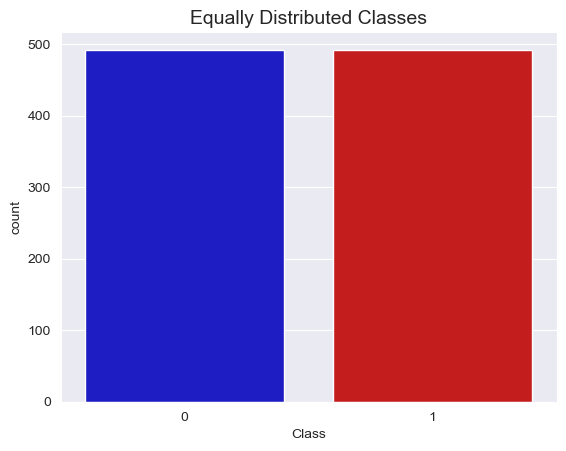

In [15]:
print('Distribution of the Classes in the subsample dataset')
print(new_df['Class'].value_counts() / len(new_df))

sns.countplot(x='Class', data=new_df, palette=colors)
plt.title('Equally Distributed Classes', fontsize=14)
plt.show()

## Correlation Matrices

Correlation matrices help us understand how strongly each feature is related to whether a transaction is fraudulent. To obtain meaningful insights, it is essential to compute correlations using the **balanced subsample**, rather than the original imbalanced dataset.

Using the full dataset would distort correlations due to the overwhelming number of non-fraud transactions.

---

### Key Observations

**Negative Correlations**
- **V17, V14, V12, V10**
- Lower values of these features are associated with a higher likelihood of fraud.

**Positive Correlations**
- **V2, V4, V11, V19**
- Higher values of these features increase the likelihood of a transaction being fraudulent.

---

### Boxplots

Boxplots are used to visualize the distribution of these features for:
- Fraudulent transactions
- Non-fraudulent transactions

This helps highlight differences in spread, median, and outliers between the two classes.

---

### Important Note
Correlation analysis must be performed on the **subsampled dataset**. Using the original imbalanced data would lead to misleading correlations caused by the dominance of non-fraud transactions.

---

### Summary
- Correlation matrices reveal which features influence fraud detection.
- Balanced data provides clearer and more reliable correlations.
- Boxplots complement correlation analysis by showing feature distributions across classes.


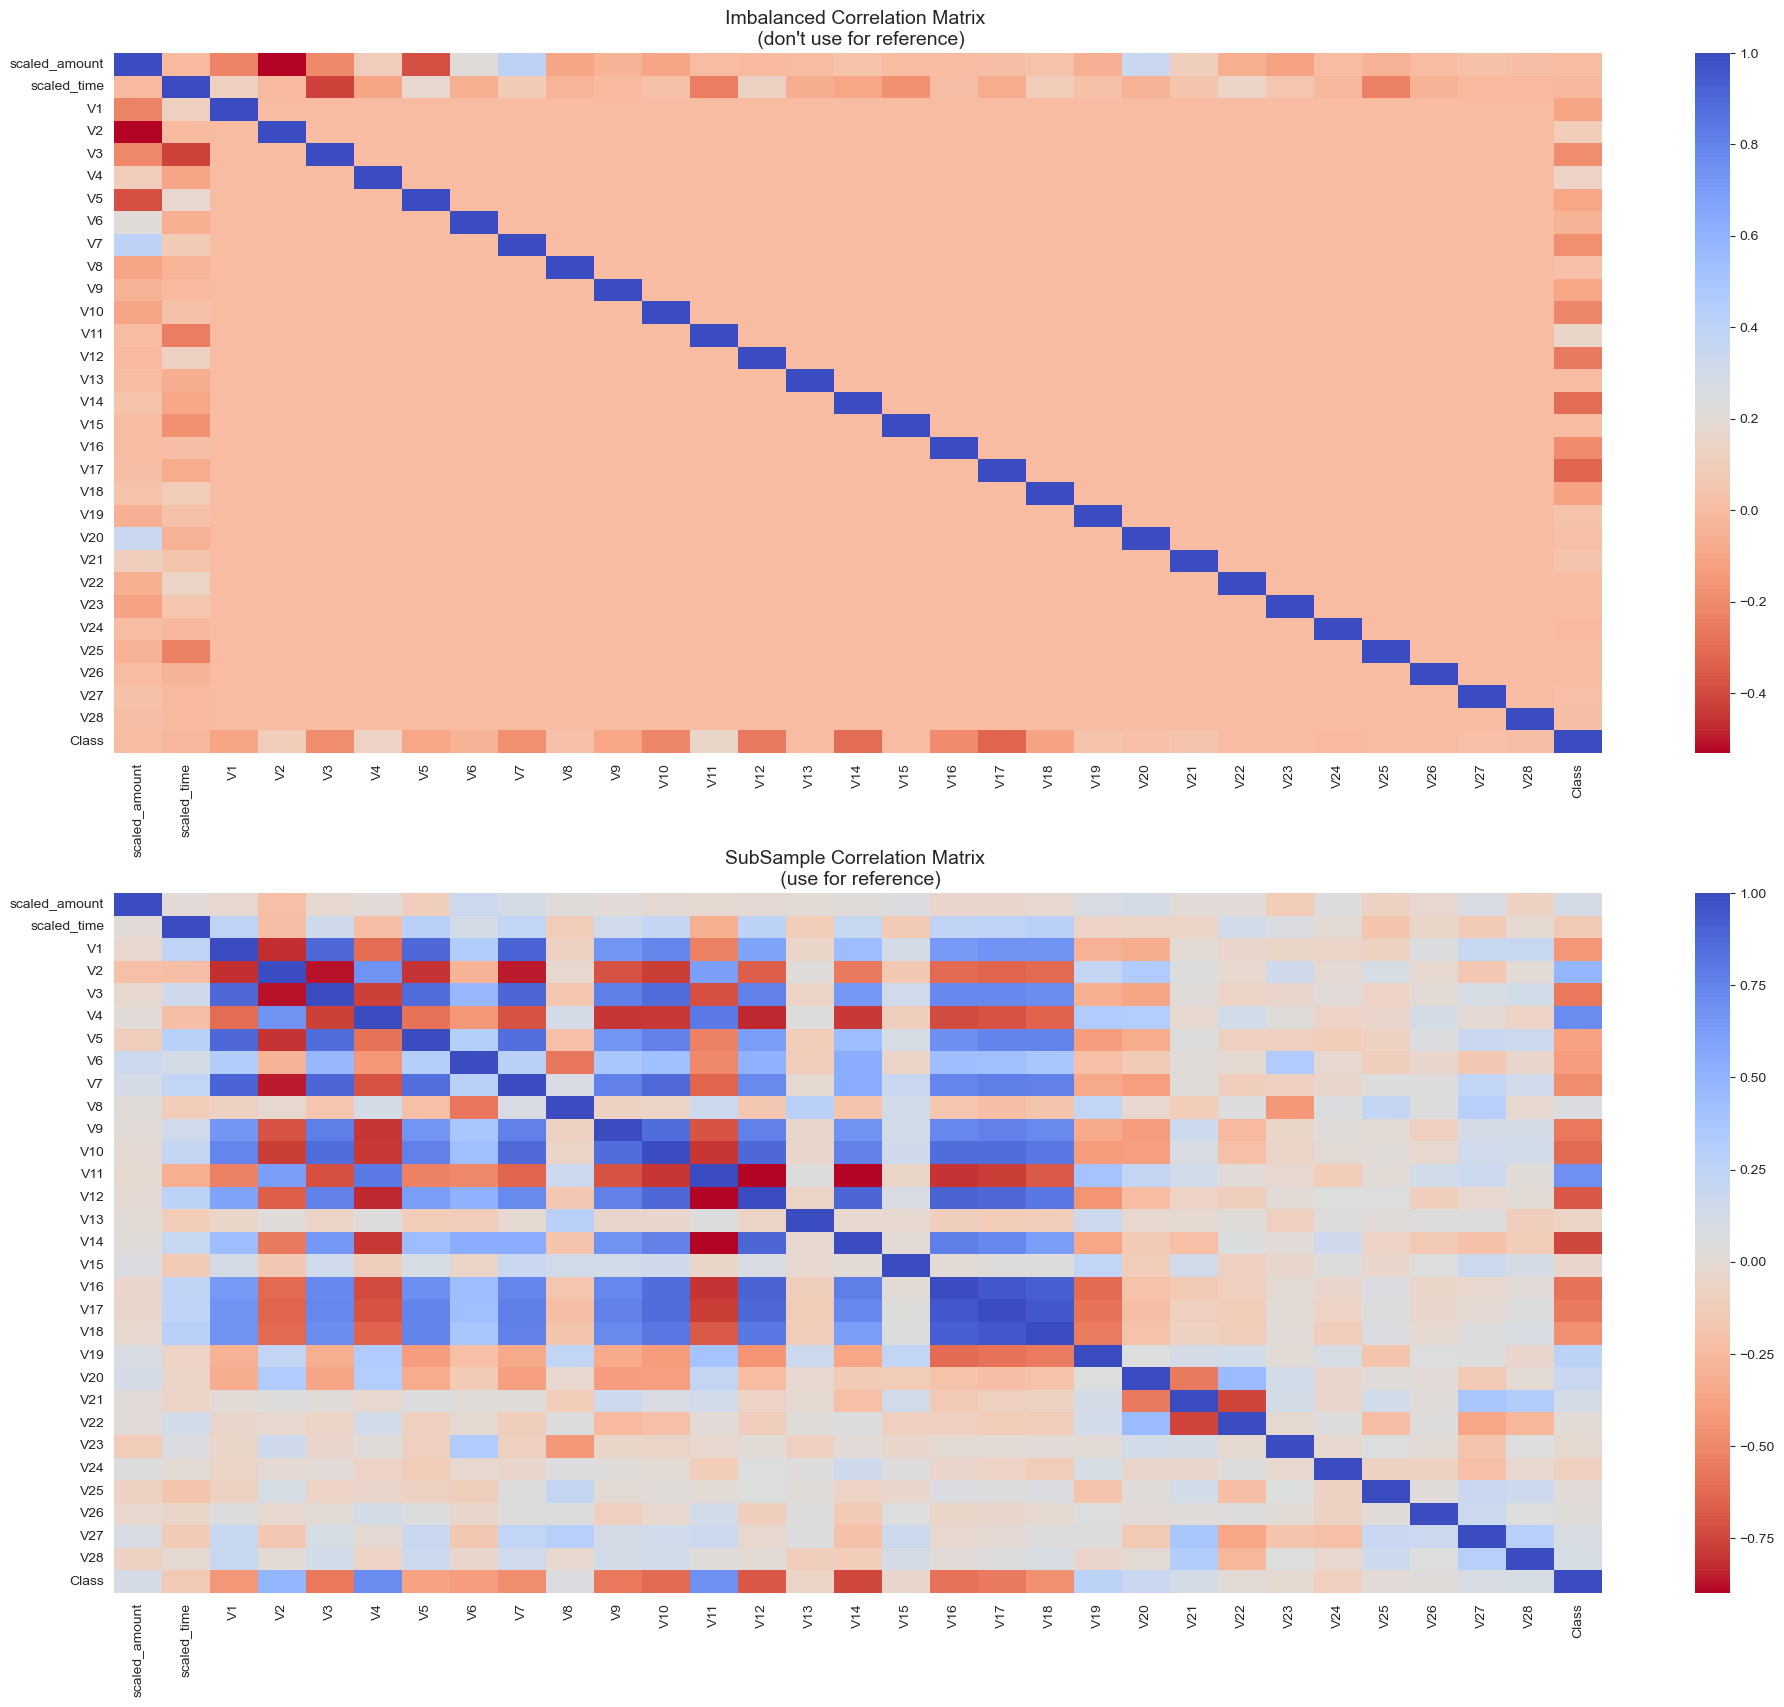

In [16]:
# Make sure we use the subsample in our correlation

f, (ax1, ax2) = plt.subplots(2, 1, figsize=(24,20))

# Entire DataFrame
corr = df.corr()
sns.heatmap(corr, cmap='coolwarm_r', annot_kws={'size':20}, ax=ax1)
ax1.set_title("Imbalanced Correlation Matrix \n (don't use for reference)", fontsize=14)


sub_sample_corr = new_df.corr()
sns.heatmap(sub_sample_corr, cmap='coolwarm_r', annot_kws={'size':20}, ax=ax2)
ax2.set_title('SubSample Correlation Matrix \n (use for reference)', fontsize=14)
plt.show()

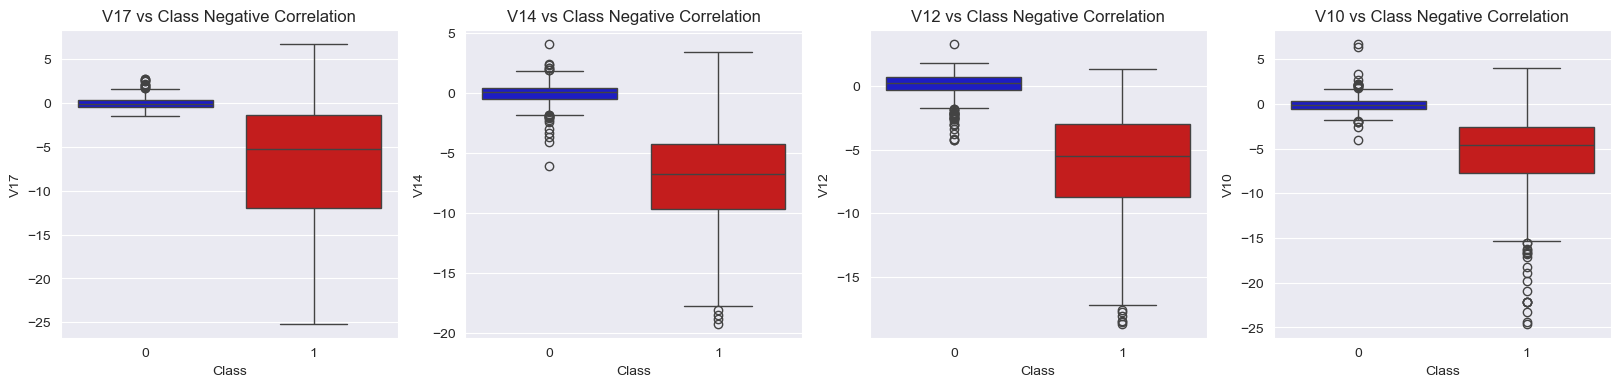

In [17]:
f, axes = plt.subplots(ncols=4, figsize=(20,4))

# Negative Correlations with our Class (The lower our feature value the more likely it will be a fraud transaction)
sns.boxplot(x="Class", y="V17", data=new_df, palette=colors, ax=axes[0])
axes[0].set_title('V17 vs Class Negative Correlation')

sns.boxplot(x="Class", y="V14", data=new_df, palette=colors, ax=axes[1])
axes[1].set_title('V14 vs Class Negative Correlation')


sns.boxplot(x="Class", y="V12", data=new_df, palette=colors, ax=axes[2])
axes[2].set_title('V12 vs Class Negative Correlation')


sns.boxplot(x="Class", y="V10", data=new_df, palette=colors, ax=axes[3])
axes[3].set_title('V10 vs Class Negative Correlation')

plt.show()

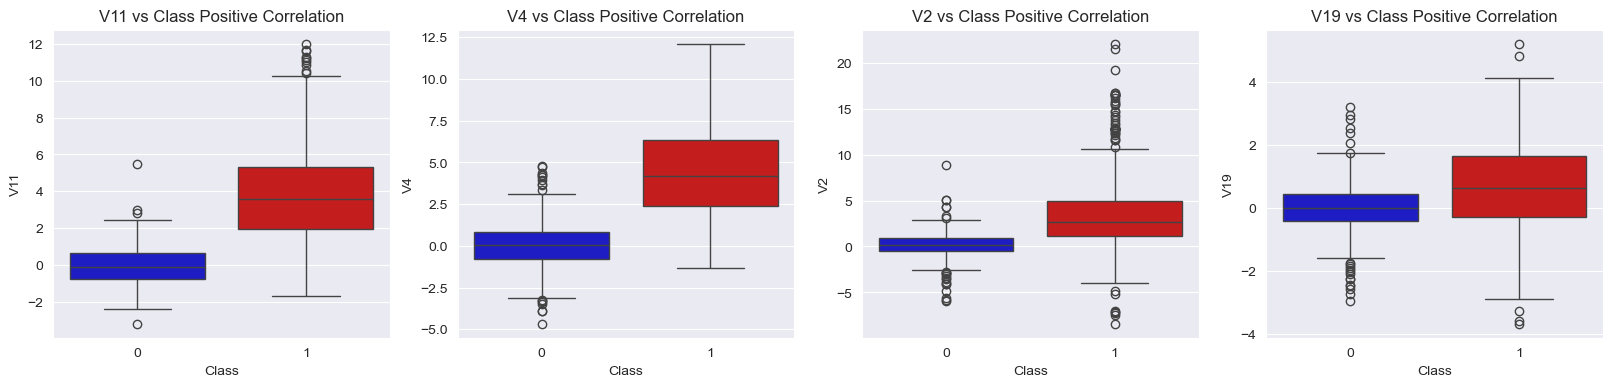

In [18]:
f, axes = plt.subplots(ncols=4, figsize=(20,4))

# Positive correlations (The higher the feature the probability increases that it will be a fraud transaction)
sns.boxplot(x="Class", y="V11", data=new_df, palette=colors, ax=axes[0])
axes[0].set_title('V11 vs Class Positive Correlation')

sns.boxplot(x="Class", y="V4", data=new_df, palette=colors, ax=axes[1])
axes[1].set_title('V4 vs Class Positive Correlation')


sns.boxplot(x="Class", y="V2", data=new_df, palette=colors, ax=axes[2])
axes[2].set_title('V2 vs Class Positive Correlation')


sns.boxplot(x="Class", y="V19", data=new_df, palette=colors, ax=axes[3])
axes[3].set_title('V19 vs Class Positive Correlation')

plt.show()

## Anomaly Detection

The main objective of this section is to remove **extreme outliers** from features that have a high correlation with the target class. Removing these extreme values can improve model accuracy by reducing noise and distortion in the data.

---

### Interquartile Range (IQR) Method

The **Interquartile Range (IQR)** is calculated as:

$$
IQR = Q_{75} - Q_{25}
$$

Using the IQR, we define thresholds beyond which data points are considered extreme outliers and removed.

---

### Boxplots

Boxplots allow us to:
- Easily identify the **25th and 75th percentiles** (edges of the box)
- Visually detect **extreme outliers** (points beyond the whiskers)

This makes boxplots a useful tool for validating outlier removal.

---

### Outlier Removal Tradeoff

To define outliers, we multiply the IQR by a constant (e.g., 1.5):

- **Lower bound:** $Q_{25} - k \times IQR$
- **Upper bound:** $Q_{75} + k \times IQR$

Where:
- Smaller values of $k$ (e.g., 1.5) detect **more outliers**
- Larger values of $k$ (e.g., 3.0) detect **fewer, more extreme outliers**

---

### The Tradeoff

A lower threshold removes more outliers but increases the risk of **information loss**, which can reduce model accuracy.
Our goal is to remove **extreme outliers only**, rather than all outliers, to avoid **underfitting**.

You can experiment with different threshold values to observe how they affect model performance.

---

### Summary

- **Visualize distributions:**
  Examine feature distributions before removal. Feature **V14** exhibits a more Gaussian distribution compared to **V12** and **V10**.

- **Determine thresholds:**
  Select a multiplier for the IQR to compute upper and lower bounds.

- **Conditional dropping:**
  Remove data points that exceed the thresholds on either extreme.

- **Boxplot verification:**
  Use boxplots to confirm that the number of extreme outliers has been significantly reduced.

---

### Final Note

After applying outlier reduction, model accuracy improved by **over 3%**. While outliers can negatively impact model performance, excessive removal can lead to information loss and underfitting. Careful threshold selection is essential.

---

### Reference

Jason Brownlee, *How to Use Statistics to Identify Outliers in Data*
(Machine Learning Mastery)


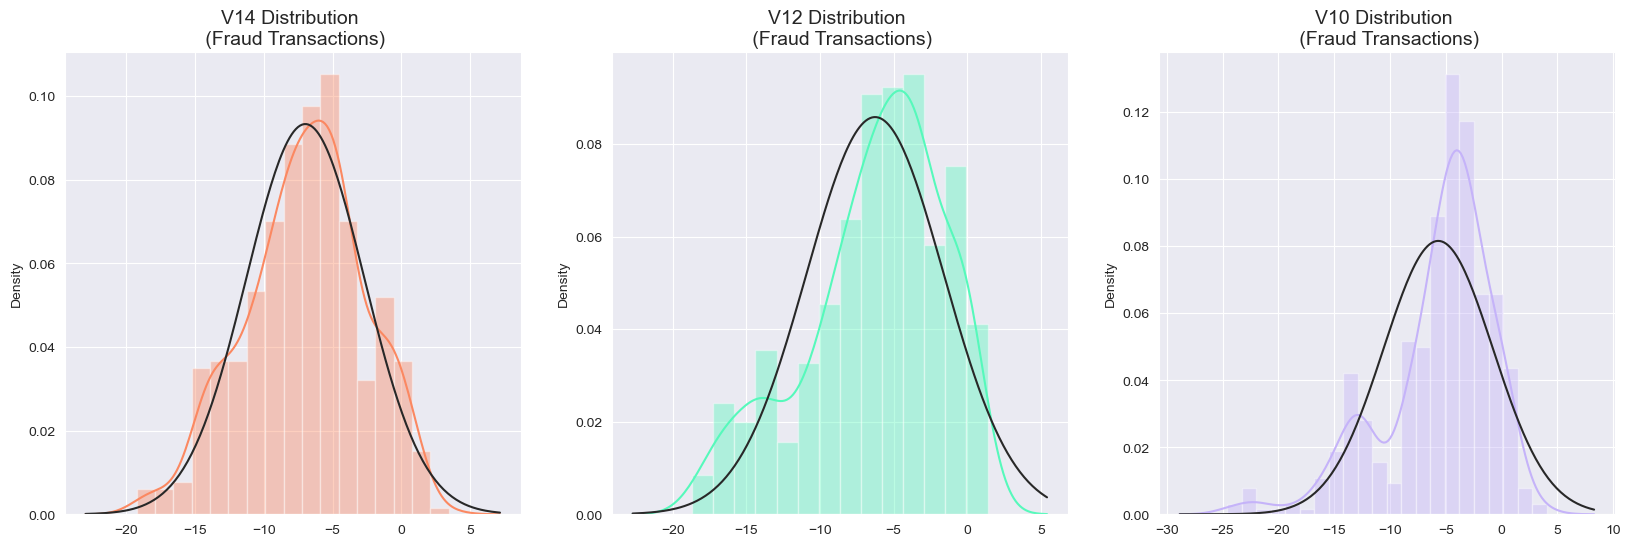

In [19]:
from scipy.stats import norm

f, (ax1, ax2, ax3) = plt.subplots(1,3, figsize=(20, 6))

v14_fraud_dist = new_df['V14'].loc[new_df['Class'] == 1].values
sns.distplot(v14_fraud_dist,ax=ax1, fit=norm, color='#FB8861')
ax1.set_title('V14 Distribution \n (Fraud Transactions)', fontsize=14)

v12_fraud_dist = new_df['V12'].loc[new_df['Class'] == 1].values
sns.distplot(v12_fraud_dist,ax=ax2, fit=norm, color='#56F9BB')
ax2.set_title('V12 Distribution \n (Fraud Transactions)', fontsize=14)


v10_fraud_dist = new_df['V10'].loc[new_df['Class'] == 1].values
sns.distplot(v10_fraud_dist,ax=ax3, fit=norm, color='#C5B3F9')
ax3.set_title('V10 Distribution \n (Fraud Transactions)', fontsize=14)

plt.show()

In [20]:
# # -----> V14 Removing Outliers (Highest Negative Correlated with Labels)
v14_fraud = new_df['V14'].loc[new_df['Class'] == 1].values
q25, q75 = np.percentile(v14_fraud, 25), np.percentile(v14_fraud, 75)
print('Quartile 25: {} | Quartile 75: {}'.format(q25, q75))
v14_iqr = q75 - q25
print('iqr: {}'.format(v14_iqr))

v14_cut_off = v14_iqr * 1.5
v14_lower, v14_upper = q25 - v14_cut_off, q75 + v14_cut_off
print('Cut Off: {}'.format(v14_cut_off))
print('V14 Lower: {}'.format(v14_lower))
print('V14 Upper: {}'.format(v14_upper))

outliers = [x for x in v14_fraud if x < v14_lower or x > v14_upper]
print('Feature V14 Outliers for Fraud Cases: {}'.format(len(outliers)))
print('V10 outliers:{}'.format(outliers))

new_df = new_df.drop(new_df[(new_df['V14'] > v14_upper) | (new_df['V14'] < v14_lower)].index)
print('----' * 44)

# -----> V12 removing outliers from fraud transactions
v12_fraud = new_df['V12'].loc[new_df['Class'] == 1].values
q25, q75 = np.percentile(v12_fraud, 25), np.percentile(v12_fraud, 75)
v12_iqr = q75 - q25

v12_cut_off = v12_iqr * 1.5
v12_lower, v12_upper = q25 - v12_cut_off, q75 + v12_cut_off
print('V12 Lower: {}'.format(v12_lower))
print('V12 Upper: {}'.format(v12_upper))
outliers = [x for x in v12_fraud if x < v12_lower or x > v12_upper]
print('V12 outliers: {}'.format(outliers))
print('Feature V12 Outliers for Fraud Cases: {}'.format(len(outliers)))
new_df = new_df.drop(new_df[(new_df['V12'] > v12_upper) | (new_df['V12'] < v12_lower)].index)
print('Number of Instances after outliers removal: {}'.format(len(new_df)))
print('----' * 44)


# Removing outliers V10 Feature
v10_fraud = new_df['V10'].loc[new_df['Class'] == 1].values
q25, q75 = np.percentile(v10_fraud, 25), np.percentile(v10_fraud, 75)
v10_iqr = q75 - q25

v10_cut_off = v10_iqr * 1.5
v10_lower, v10_upper = q25 - v10_cut_off, q75 + v10_cut_off
print('V10 Lower: {}'.format(v10_lower))
print('V10 Upper: {}'.format(v10_upper))
outliers = [x for x in v10_fraud if x < v10_lower or x > v10_upper]
print('V10 outliers: {}'.format(outliers))
print('Feature V10 Outliers for Fraud Cases: {}'.format(len(outliers)))
new_df = new_df.drop(new_df[(new_df['V10'] > v10_upper) | (new_df['V10'] < v10_lower)].index)
print('Number of Instances after outliers removal: {}'.format(len(new_df)))

Quartile 25: -9.692722964972386 | Quartile 75: -4.282820849486865
iqr: 5.409902115485521
Cut Off: 8.114853173228282
V14 Lower: -17.807576138200666
V14 Upper: 3.8320323237414167
Feature V14 Outliers for Fraud Cases: 4
V10 outliers:[-18.4937733551053, -18.0499976898594, -19.2143254902614, -18.8220867423816]
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
V12 Lower: -17.3430371579634
V12 Upper: 5.776973384895937
V12 outliers: [-18.5536970096458, -18.6837146333443, -18.4311310279993, -18.0475965708216]
Feature V12 Outliers for Fraud Cases: 4
Number of Instances after outliers removal: 975
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
V10 Lower: -14.89885463232024
V10 Upper: 4.92033495834214
V10 outliers: [-18.2711681738888, -24.403184

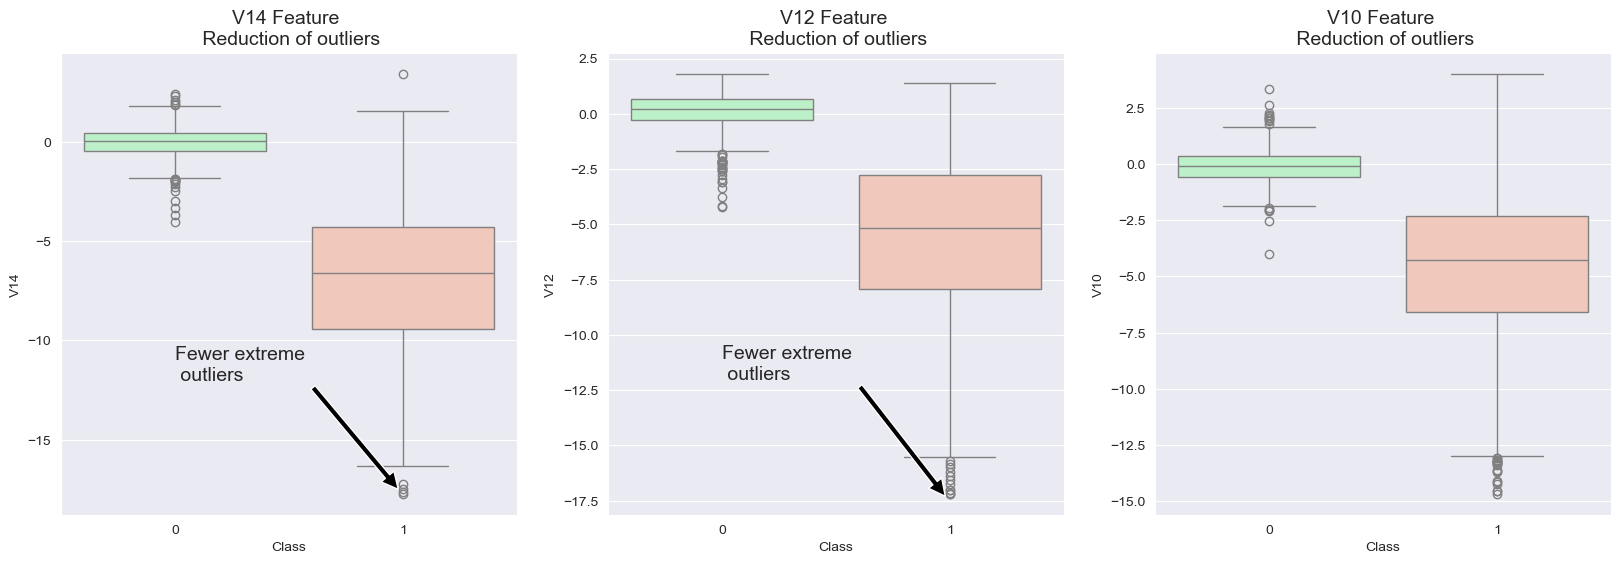

In [21]:
f,(ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20,6))

colors = ['#B3F9C5', '#f9c5b3']
# Boxplots with outliers removed
# Feature V14
sns.boxplot(x="Class", y="V14", data=new_df,ax=ax1, palette=colors)
ax1.set_title("V14 Feature \n Reduction of outliers", fontsize=14)
ax1.annotate('Fewer extreme \n outliers', xy=(0.98, -17.5), xytext=(0, -12),
            arrowprops=dict(facecolor='black'),
            fontsize=14)

# Feature 12
sns.boxplot(x="Class", y="V12", data=new_df, ax=ax2, palette=colors)
ax2.set_title("V12 Feature \n Reduction of outliers", fontsize=14)
ax2.annotate('Fewer extreme \n outliers', xy=(0.98, -17.3), xytext=(0, -12),
            arrowprops=dict(facecolor='black'),
            fontsize=14)

# Feature V10
sns.boxplot(x="Class", y="V10", data=new_df, ax=ax3, palette=colors)
ax3.set_title("V10 Feature \n Reduction of outliers", fontsize=14)
ax3.annotate('Fewer extreme \n outliers', xy=(0.95, -16.5), xytext=(0, -12),
            arrowprops=dict(facecolor='black'),
            fontsize=14)


plt.show()

In [22]:
# New_df is from the random undersample data (fewer instances)
X = new_df.drop('Class', axis=1)
y = new_df['Class']


# T-SNE Implementation
t0 = time.time()
X_reduced_tsne = TSNE(n_components=2, random_state=42).fit_transform(X.values)
t1 = time.time()
print("T-SNE took {:.2} s".format(t1 - t0))

# PCA Implementation
t0 = time.time()
X_reduced_pca = PCA(n_components=2, random_state=42).fit_transform(X.values)
t1 = time.time()
print("PCA took {:.2} s".format(t1 - t0))

# TruncatedSVD
t0 = time.time()
X_reduced_svd = TruncatedSVD(n_components=2, algorithm='randomized', random_state=42).fit_transform(X.values)
t1 = time.time()
print("Truncated SVD took {:.2} s".format(t1 - t0))

T-SNE took 1.2 s
PCA took 0.008 s
Truncated SVD took 0.002 s


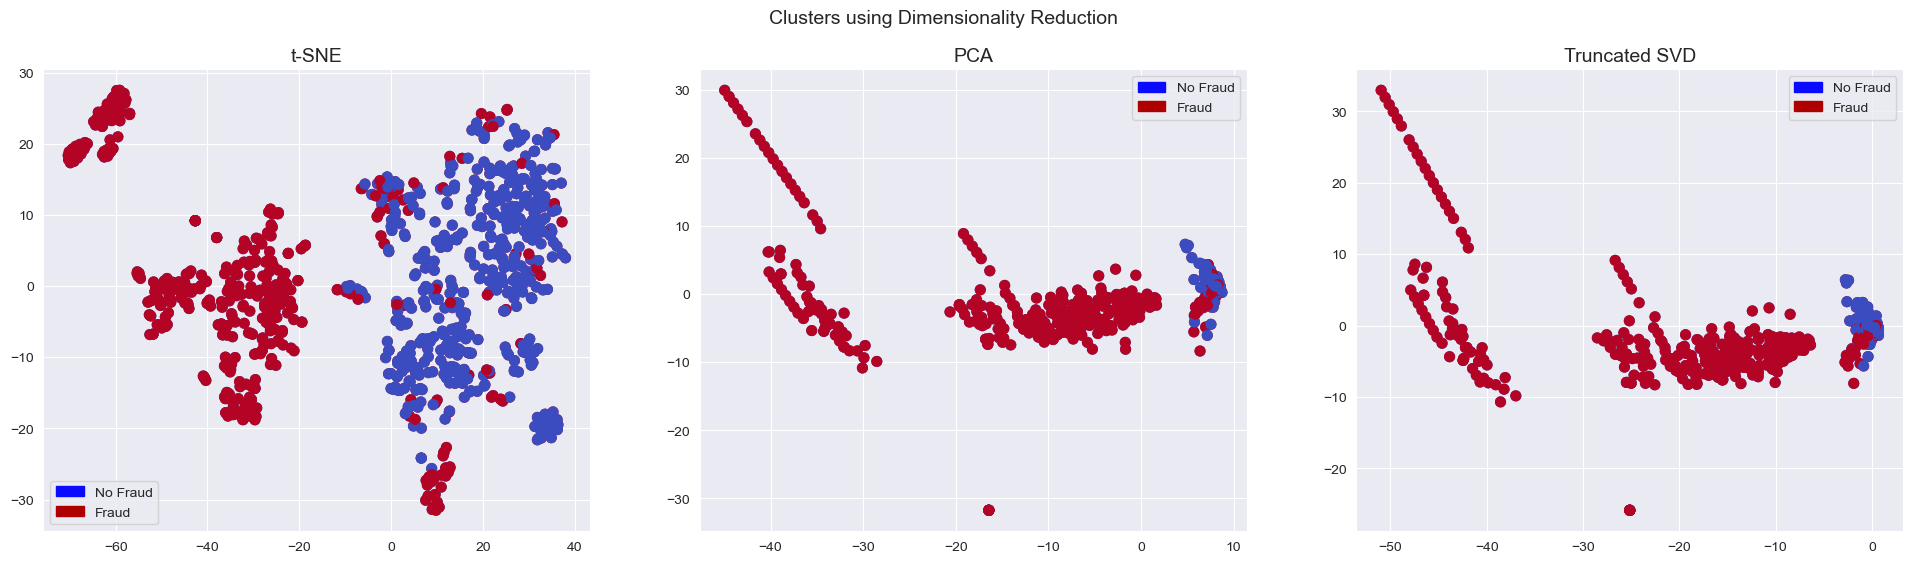

In [23]:
f, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(24,6))
# labels = ['No Fraud', 'Fraud']
f.suptitle('Clusters using Dimensionality Reduction', fontsize=14)


blue_patch = mpatches.Patch(color='#0A0AFF', label='No Fraud')
red_patch = mpatches.Patch(color='#AF0000', label='Fraud')


# t-SNE scatter plot
ax1.scatter(X_reduced_tsne[:,0], X_reduced_tsne[:,1], c=(y == 0), cmap='coolwarm', label='No Fraud', linewidths=2)
ax1.scatter(X_reduced_tsne[:,0], X_reduced_tsne[:,1], c=(y == 1), cmap='coolwarm', label='Fraud', linewidths=2)
ax1.set_title('t-SNE', fontsize=14)

ax1.grid(True)

ax1.legend(handles=[blue_patch, red_patch])


# PCA scatter plot
ax2.scatter(X_reduced_pca[:,0], X_reduced_pca[:,1], c=(y == 0), cmap='coolwarm', label='No Fraud', linewidths=2)
ax2.scatter(X_reduced_pca[:,0], X_reduced_pca[:,1], c=(y == 1), cmap='coolwarm', label='Fraud', linewidths=2)
ax2.set_title('PCA', fontsize=14)

ax2.grid(True)

ax2.legend(handles=[blue_patch, red_patch])

# TruncatedSVD scatter plot
ax3.scatter(X_reduced_svd[:,0], X_reduced_svd[:,1], c=(y == 0), cmap='coolwarm', label='No Fraud', linewidths=2)
ax3.scatter(X_reduced_svd[:,0], X_reduced_svd[:,1], c=(y == 1), cmap='coolwarm', label='Fraud', linewidths=2)
ax3.set_title('Truncated SVD', fontsize=14)

ax3.grid(True)

ax3.legend(handles=[blue_patch, red_patch])

plt.show()

## Classifiers (Under-Sampling)

In this section, we train and evaluate **four different classifiers** to determine which model is most effective at detecting fraudulent transactions. Before training, the data is split into **training and testing sets**, and features are separated from the target labels.

---

### Summary of Results

- **Logistic Regression** outperforms the other three classifiers in most cases.
- **GridSearchCV** is used to identify the optimal hyperparameters for each classifier.
- Logistic Regression achieves the **highest Receiver Operating Characteristic (ROC) score**, indicating strong separation between fraud and non-fraud transactions.

Due to its superior performance, Logistic Regression is selected for further analysis.

---

### Learning Curves Interpretation

Learning curves provide insight into model bias and variance:

- A **large gap** between training and cross-validation scores suggests **overfitting** (high variance).
- **Low scores** in both training and cross-validation indicate **underfitting** (high bias).
- Logistic Regression demonstrates the **best balance**, with strong and consistent performance across both training and cross-validation sets.

---

### Key Takeaway

Among the evaluated classifiers, **Logistic Regression** provides the most reliable performance on the under-sampled dataset, making it the best candidate for fraud detection in this setting.


In [24]:
# Undersampling before cross validating (prone to overfit)
X = new_df.drop('Class', axis=1)
y = new_df['Class']

In [25]:
# Our data is already scaled we should split our training and test sets
from sklearn.model_selection import train_test_split

# This is explicitly used for undersampling.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [26]:
# Turn the values into an array for feeding the classification algorithms.
X_train = X_train.values
X_test = X_test.values
y_train = y_train.values
y_test = y_test.values

In [27]:
# Let's implement simple classifiers

classifiers = {
    "LogisiticRegression": LogisticRegression(),
    "KNearest": KNeighborsClassifier(),
    "Support Vector Classifier": SVC(),
    "DecisionTreeClassifier": DecisionTreeClassifier()
}

In [28]:
# Wow our scores are getting even high scores even when applying cross validation.
from sklearn.model_selection import cross_val_score


for key, classifier in classifiers.items():
    classifier.fit(X_train, y_train)
    training_score = cross_val_score(classifier, X_train, y_train, cv=5)
    print("Classifiers: ", classifier.__class__.__name__, "Has a training score of", round(training_score.mean(), 2) * 100, "% accuracy score")

Classifiers:  LogisticRegression Has a training score of 94.0 % accuracy score
Classifiers:  KNeighborsClassifier Has a training score of 92.0 % accuracy score
Classifiers:  SVC Has a training score of 93.0 % accuracy score
Classifiers:  DecisionTreeClassifier Has a training score of 89.0 % accuracy score


In [29]:
# Use GridSearchCV to find the best parameters.
from sklearn.model_selection import GridSearchCV


# Logistic Regression
log_reg_params = {"penalty": ['l1', 'l2'], 'C': [0.001, 0.01, 0.1, 1, 10, 100, 1000]}



grid_log_reg = GridSearchCV(LogisticRegression(), log_reg_params)
grid_log_reg.fit(X_train, y_train)
# We automatically get the logistic regression with the best parameters.
log_reg = grid_log_reg.best_estimator_

knears_params = {"n_neighbors": list(range(2,5,1)), 'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute']}

grid_knears = GridSearchCV(KNeighborsClassifier(), knears_params)
grid_knears.fit(X_train, y_train)
# KNears best estimator
knears_neighbors = grid_knears.best_estimator_

# Support Vector Classifier
svc_params = {'C': [0.5, 0.7, 0.9, 1], 'kernel': ['rbf', 'poly', 'sigmoid', 'linear']}
grid_svc = GridSearchCV(SVC(), svc_params)
grid_svc.fit(X_train, y_train)

# SVC best estimator
svc = grid_svc.best_estimator_

# DecisionTree Classifier
tree_params = {"criterion": ["gini", "entropy"], "max_depth": list(range(2,4,1)),
              "min_samples_leaf": list(range(5,7,1))}
grid_tree = GridSearchCV(DecisionTreeClassifier(), tree_params)
grid_tree.fit(X_train, y_train)

# tree best estimator
tree_clf = grid_tree.best_estimator_

In [30]:
# Overfitting Case

log_reg_score = cross_val_score(log_reg, X_train, y_train, cv=5)
print('Logistic Regression Cross Validation Score: ', round(log_reg_score.mean() * 100, 2).astype(str) + '%')


knears_score = cross_val_score(knears_neighbors, X_train, y_train, cv=5)
print('Knears Neighbors Cross Validation Score', round(knears_score.mean() * 100, 2).astype(str) + '%')

svc_score = cross_val_score(svc, X_train, y_train, cv=5)
print('Support Vector Classifier Cross Validation Score', round(svc_score.mean() * 100, 2).astype(str) + '%')

tree_score = cross_val_score(tree_clf, X_train, y_train, cv=5)
print('DecisionTree Classifier Cross Validation Score', round(tree_score.mean() * 100, 2).astype(str) + '%')

Logistic Regression Cross Validation Score:  94.32%
Knears Neighbors Cross Validation Score 92.59%
Support Vector Classifier Cross Validation Score 93.52%
DecisionTree Classifier Cross Validation Score 93.26%


In [32]:
# We will undersample during cross validating
undersample_X = df.drop('Class', axis=1)
undersample_y = df['Class']

for train_index, test_index in sss.split(undersample_X, undersample_y):
    print("Train:", train_index, "Test:", test_index)
    undersample_Xtrain, undersample_Xtest = undersample_X.iloc[train_index], undersample_X.iloc[test_index]
    undersample_ytrain, undersample_ytest = undersample_y.iloc[train_index], undersample_y.iloc[test_index]

undersample_Xtrain = undersample_Xtrain.values
undersample_Xtest = undersample_Xtest.values
undersample_ytrain = undersample_ytrain.values
undersample_ytest = undersample_ytest.values

undersample_accuracy = []
undersample_precision = []
undersample_recall = []
undersample_f1 = []
undersample_auc = []

# Implementing NearMiss Technique
# Distribution of NearMiss (Just to see how it distributes the labels we won't use these variables)
X_nearmiss, y_nearmiss = NearMiss().fit_resample(undersample_X.values, undersample_y.values)
print('NearMiss Label Distribution: {}'.format(Counter(y_nearmiss)))
# Cross Validating the right way

for train, test in sss.split(undersample_Xtrain, undersample_ytrain):
    undersample_pipeline = imbalanced_make_pipeline(NearMiss(sampling_strategy='majority'), log_reg) # SMOTE happens during Cross Validation not before..
    undersample_model = undersample_pipeline.fit(undersample_Xtrain[train], undersample_ytrain[train])
    undersample_prediction = undersample_model.predict(undersample_Xtrain[test])

    undersample_accuracy.append(undersample_pipeline.score(original_Xtrain[test], original_ytrain[test]))
    undersample_precision.append(precision_score(original_ytrain[test], undersample_prediction))
    undersample_recall.append(recall_score(original_ytrain[test], undersample_prediction))
    undersample_f1.append(f1_score(original_ytrain[test], undersample_prediction))
    undersample_auc.append(roc_auc_score(original_ytrain[test], undersample_prediction))

Train: [ 56955  56956  56957 ... 284804 284805 284806] Test: [    0     1     2 ... 60688 60695 61012]
Train: [     0      1      2 ... 284804 284805 284806] Test: [ 56955  56956  56957 ... 119792 120214 120423]
Train: [     0      1      2 ... 284804 284805 284806] Test: [113914 113915 113916 ... 176649 176787 177272]
Train: [     0      1      2 ... 284804 284805 284806] Test: [170872 170873 170874 ... 231526 231702 232151]
Train: [     0      1      2 ... 231526 231702 232151] Test: [227836 227837 227838 ... 284804 284805 284806]
NearMiss Label Distribution: Counter({0: 492, 1: 492})


In [33]:
# Let's Plot LogisticRegression Learning Curve
from sklearn.model_selection import ShuffleSplit
from sklearn.model_selection import learning_curve

def plot_learning_curve(estimator1, estimator2, estimator3, estimator4, X, y, ylim=None, cv=None,
                        n_jobs=1, train_sizes=np.linspace(.1, 1.0, 5)):
    f, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2,2, figsize=(20,14), sharey=True)
    if ylim is not None:
        plt.ylim(*ylim)
    # First Estimator
    train_sizes, train_scores, test_scores = learning_curve(
        estimator1, X, y, cv=cv, n_jobs=n_jobs, train_sizes=train_sizes)
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)
    ax1.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1,
                     color="#ff9124")
    ax1.fill_between(train_sizes, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.1, color="#2492ff")
    ax1.plot(train_sizes, train_scores_mean, 'o-', color="#ff9124",
             label="Training score")
    ax1.plot(train_sizes, test_scores_mean, 'o-', color="#2492ff",
             label="Cross-validation score")
    ax1.set_title("Logistic Regression Learning Curve", fontsize=14)
    ax1.set_xlabel('Training size (m)')
    ax1.set_ylabel('Score')
    ax1.grid(True)
    ax1.legend(loc="best")

    # Second Estimator
    train_sizes, train_scores, test_scores = learning_curve(
        estimator2, X, y, cv=cv, n_jobs=n_jobs, train_sizes=train_sizes)
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)
    ax2.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1,
                     color="#ff9124")
    ax2.fill_between(train_sizes, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.1, color="#2492ff")
    ax2.plot(train_sizes, train_scores_mean, 'o-', color="#ff9124",
             label="Training score")
    ax2.plot(train_sizes, test_scores_mean, 'o-', color="#2492ff",
             label="Cross-validation score")
    ax2.set_title("Knears Neighbors Learning Curve", fontsize=14)
    ax2.set_xlabel('Training size (m)')
    ax2.set_ylabel('Score')
    ax2.grid(True)
    ax2.legend(loc="best")

    # Third Estimator
    train_sizes, train_scores, test_scores = learning_curve(
        estimator3, X, y, cv=cv, n_jobs=n_jobs, train_sizes=train_sizes)
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)
    ax3.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1,
                     color="#ff9124")
    ax3.fill_between(train_sizes, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.1, color="#2492ff")
    ax3.plot(train_sizes, train_scores_mean, 'o-', color="#ff9124",
             label="Training score")
    ax3.plot(train_sizes, test_scores_mean, 'o-', color="#2492ff",
             label="Cross-validation score")
    ax3.set_title("Support Vector Classifier \n Learning Curve", fontsize=14)
    ax3.set_xlabel('Training size (m)')
    ax3.set_ylabel('Score')
    ax3.grid(True)
    ax3.legend(loc="best")

    # Fourth Estimator
    train_sizes, train_scores, test_scores = learning_curve(
        estimator4, X, y, cv=cv, n_jobs=n_jobs, train_sizes=train_sizes)
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)
    ax4.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1,
                     color="#ff9124")
    ax4.fill_between(train_sizes, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.1, color="#2492ff")
    ax4.plot(train_sizes, train_scores_mean, 'o-', color="#ff9124",
             label="Training score")
    ax4.plot(train_sizes, test_scores_mean, 'o-', color="#2492ff",
             label="Cross-validation score")
    ax4.set_title("Decision Tree Classifier \n Learning Curve", fontsize=14)
    ax4.set_xlabel('Training size (m)')
    ax4.set_ylabel('Score')
    ax4.grid(True)
    ax4.legend(loc="best")
    return plt

<module 'matplotlib.pyplot' from 'C:\\Users\\notclency\\miniconda3\\envs\\tf\\lib\\site-packages\\matplotlib\\pyplot.py'>

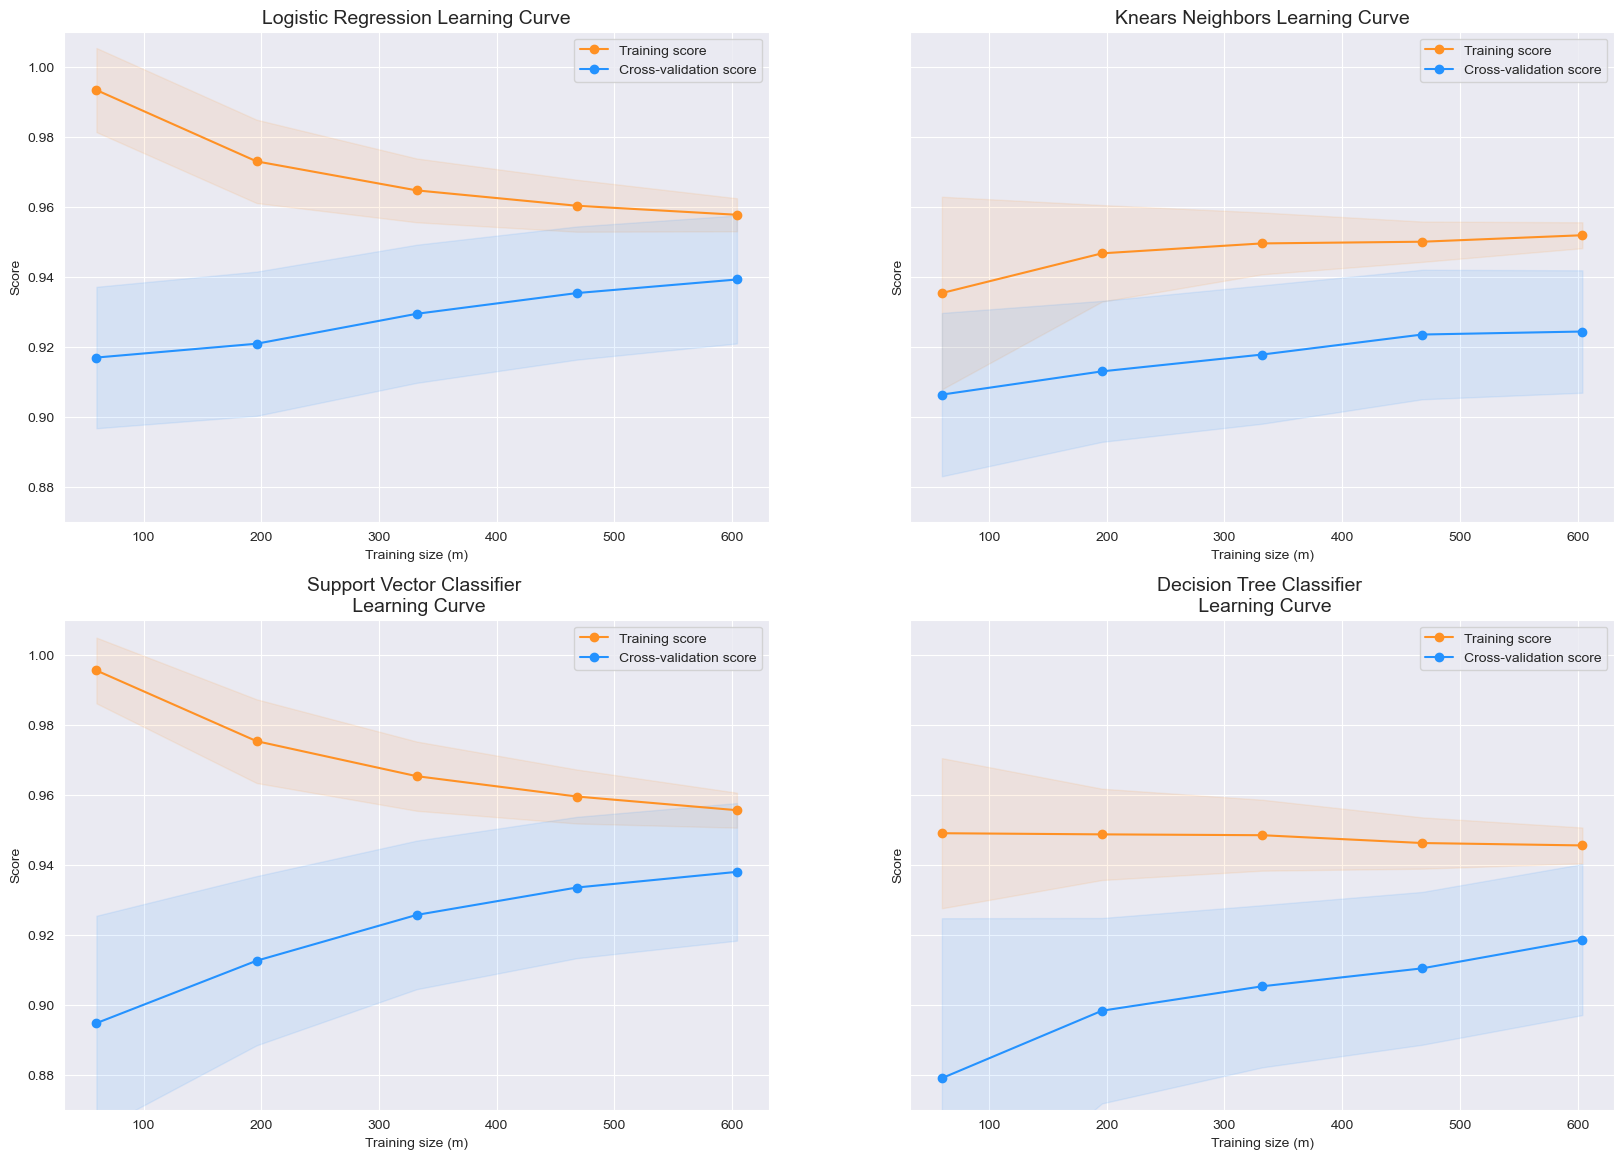

In [34]:
cv = ShuffleSplit(n_splits=100, test_size=0.2, random_state=42)
plot_learning_curve(log_reg, knears_neighbors, svc, tree_clf, X_train, y_train, (0.87, 1.01), cv=cv, n_jobs=4)

In [35]:
from sklearn.metrics import roc_curve
from sklearn.model_selection import cross_val_predict
# Create a DataFrame with all the scores and the classifiers names.

log_reg_pred = cross_val_predict(log_reg, X_train, y_train, cv=5,
                             method="decision_function")

knears_pred = cross_val_predict(knears_neighbors, X_train, y_train, cv=5)

svc_pred = cross_val_predict(svc, X_train, y_train, cv=5,
                             method="decision_function")

tree_pred = cross_val_predict(tree_clf, X_train, y_train, cv=5)

In [36]:
from sklearn.metrics import roc_auc_score

print('Logistic Regression: ', roc_auc_score(y_train, log_reg_pred))
print('KNears Neighbors: ', roc_auc_score(y_train, knears_pred))
print('Support Vector Classifier: ', roc_auc_score(y_train, svc_pred))
print('Decision Tree Classifier: ', roc_auc_score(y_train, tree_pred))

Logistic Regression:  0.9704117931842581
KNears Neighbors:  0.923338689194025
Support Vector Classifier:  0.9695908730520687
Decision Tree Classifier:  0.9299025420458452


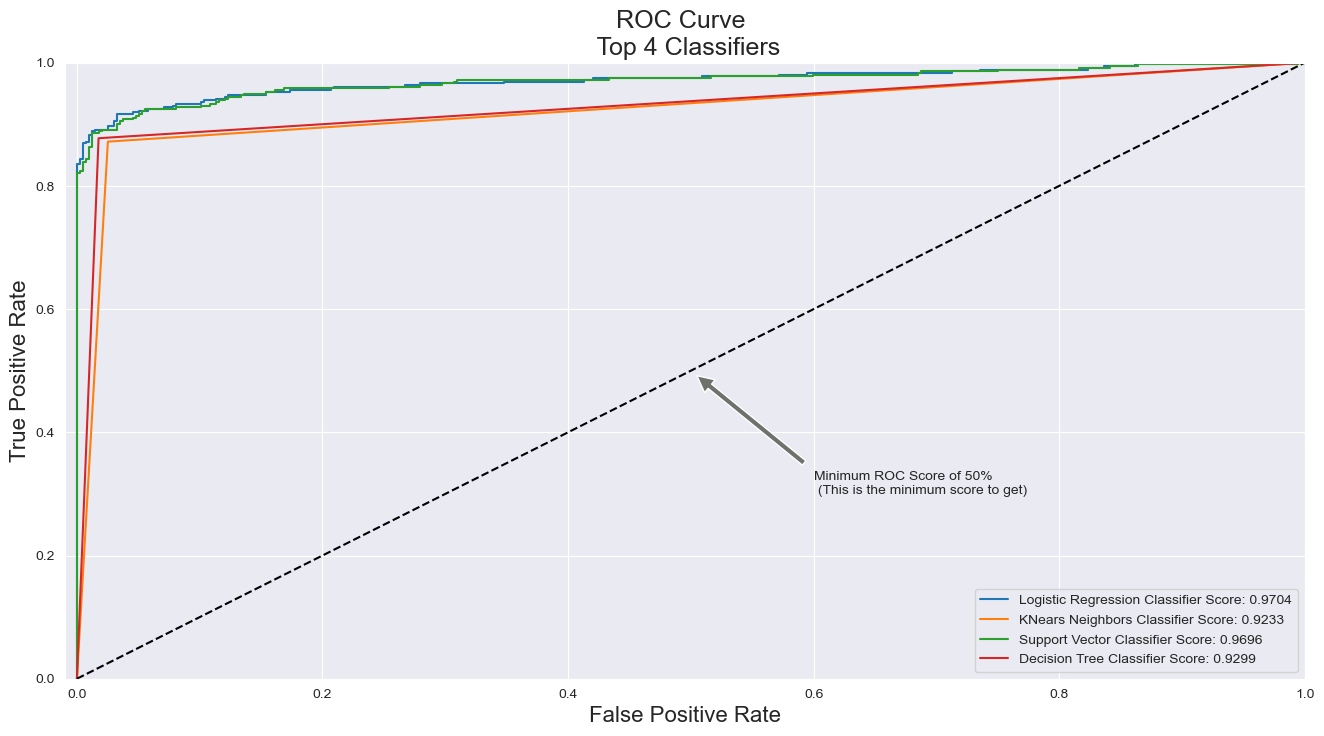

In [37]:
log_fpr, log_tpr, log_thresold = roc_curve(y_train, log_reg_pred)
knear_fpr, knear_tpr, knear_threshold = roc_curve(y_train, knears_pred)
svc_fpr, svc_tpr, svc_threshold = roc_curve(y_train, svc_pred)
tree_fpr, tree_tpr, tree_threshold = roc_curve(y_train, tree_pred)


def graph_roc_curve_multiple(log_fpr, log_tpr, knear_fpr, knear_tpr, svc_fpr, svc_tpr, tree_fpr, tree_tpr):
    plt.figure(figsize=(16,8))
    plt.title('ROC Curve \n Top 4 Classifiers', fontsize=18)
    plt.plot(log_fpr, log_tpr, label='Logistic Regression Classifier Score: {:.4f}'.format(roc_auc_score(y_train, log_reg_pred)))
    plt.plot(knear_fpr, knear_tpr, label='KNears Neighbors Classifier Score: {:.4f}'.format(roc_auc_score(y_train, knears_pred)))
    plt.plot(svc_fpr, svc_tpr, label='Support Vector Classifier Score: {:.4f}'.format(roc_auc_score(y_train, svc_pred)))
    plt.plot(tree_fpr, tree_tpr, label='Decision Tree Classifier Score: {:.4f}'.format(roc_auc_score(y_train, tree_pred)))
    plt.plot([0, 1], [0, 1], 'k--')
    plt.axis([-0.01, 1, 0, 1])
    plt.xlabel('False Positive Rate', fontsize=16)
    plt.ylabel('True Positive Rate', fontsize=16)
    plt.annotate('Minimum ROC Score of 50% \n (This is the minimum score to get)', xy=(0.5, 0.5), xytext=(0.6, 0.3),
                arrowprops=dict(facecolor='#6E726D', shrink=0.05),
                )
    plt.legend()

graph_roc_curve_multiple(log_fpr, log_tpr, knear_fpr, knear_tpr, svc_fpr, svc_tpr, tree_fpr, tree_tpr)
plt.show()

## A Deeper Look into Logistic Regression

In this section, we take a closer look at the **Logistic Regression classifier** and how it performs in detecting fraud.

---

### Key Terms

- **True Positives (TP):** Correctly classified fraud transactions
- **False Positives (FP):** Non-fraud transactions incorrectly classified as fraud
- **True Negatives (TN):** Correctly classified non-fraud transactions
- **False Negatives (FN):** Fraud transactions incorrectly classified as non-fraud

---

### Metrics

- **Precision:**
$$
\text{Precision} = \frac{TP}{TP + FP}
$$
Measures how sure the model is when it predicts a transaction as fraud. Higher precision means fewer false positives.

- **Recall:**
$$
\text{Recall} = \frac{TP}{TP + FN}
$$
Measures how many of the actual fraud transactions the model is able to detect.

---

### Precision / Recall Tradeoff

- A **high precision** model is very selective but may miss some fraud cases (lower recall).
- Lowering the precision threshold allows the model to detect more frauds, increasing recall, but may also increase false positives.

**Example:**
If the model has 95% precision for 5 fraud cases, lowering the threshold may allow it to detect 5 additional frauds with slightly lower confidence (e.g., 90%), improving recall.

---

### Summary

- Precision slightly decreases between **0.90 and 0.92**, but remains high.
- Recall remains decent, indicating that Logistic Regression balances **precision and recall** effectively on this dataset.


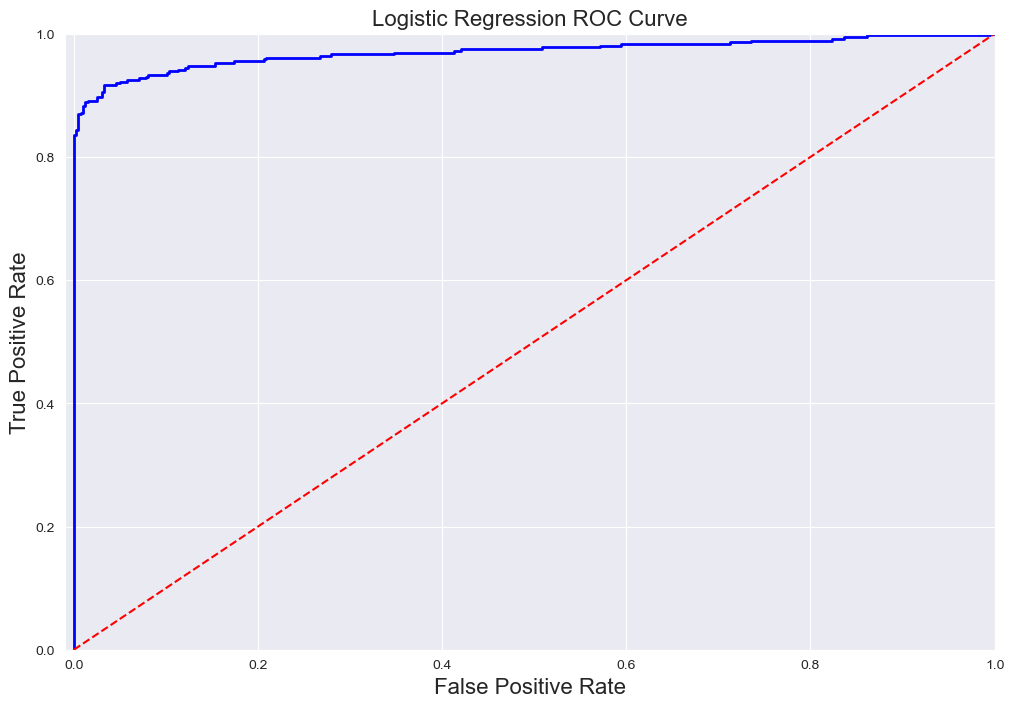

In [38]:
def logistic_roc_curve(log_fpr, log_tpr):
    plt.figure(figsize=(12,8))
    plt.title('Logistic Regression ROC Curve', fontsize=16)
    plt.plot(log_fpr, log_tpr, 'b-', linewidth=2)
    plt.plot([0, 1], [0, 1], 'r--')
    plt.xlabel('False Positive Rate', fontsize=16)
    plt.ylabel('True Positive Rate', fontsize=16)
    plt.axis([-0.01,1,0,1])


logistic_roc_curve(log_fpr, log_tpr)
plt.show()

In [39]:
from sklearn.metrics import precision_recall_curve

precision, recall, threshold = precision_recall_curve(y_train, log_reg_pred)

In [40]:
from sklearn.metrics import recall_score, precision_score, f1_score, accuracy_score
y_pred = log_reg.predict(X_train)

# Overfitting Case
print('---' * 45)
print('Overfitting: \n')
print('Recall Score: {:.2f}'.format(recall_score(y_train, y_pred)))
print('Precision Score: {:.2f}'.format(precision_score(y_train, y_pred)))
print('F1 Score: {:.2f}'.format(f1_score(y_train, y_pred)))
print('Accuracy Score: {:.2f}'.format(accuracy_score(y_train, y_pred)))
print('---' * 45)

# How it should look like
print('---' * 45)
print('How it should be:\n')
print("Accuracy Score: {:.2f}".format(np.mean(undersample_accuracy)))
print("Precision Score: {:.2f}".format(np.mean(undersample_precision)))
print("Recall Score: {:.2f}".format(np.mean(undersample_recall)))
print("F1 Score: {:.2f}".format(np.mean(undersample_f1)))
print('---' * 45)

---------------------------------------------------------------------------------------------------------------------------------------
Overfitting: 

Recall Score: 0.96
Precision Score: 0.64
F1 Score: 0.77
Accuracy Score: 0.72
---------------------------------------------------------------------------------------------------------------------------------------
---------------------------------------------------------------------------------------------------------------------------------------
How it should be:

Accuracy Score: 0.60
Precision Score: 0.00
Recall Score: 0.43
F1 Score: 0.00
---------------------------------------------------------------------------------------------------------------------------------------


In [41]:
undersample_y_score = log_reg.decision_function(original_Xtest)

In [42]:
from sklearn.metrics import average_precision_score

undersample_average_precision = average_precision_score(original_ytest, undersample_y_score)

print('Average precision-recall score: {0:0.2f}'.format(
      undersample_average_precision))

Average precision-recall score: 0.03


Text(0.5, 1.0, 'UnderSampling Precision-Recall curve: \n Average Precision-Recall Score =0.03')

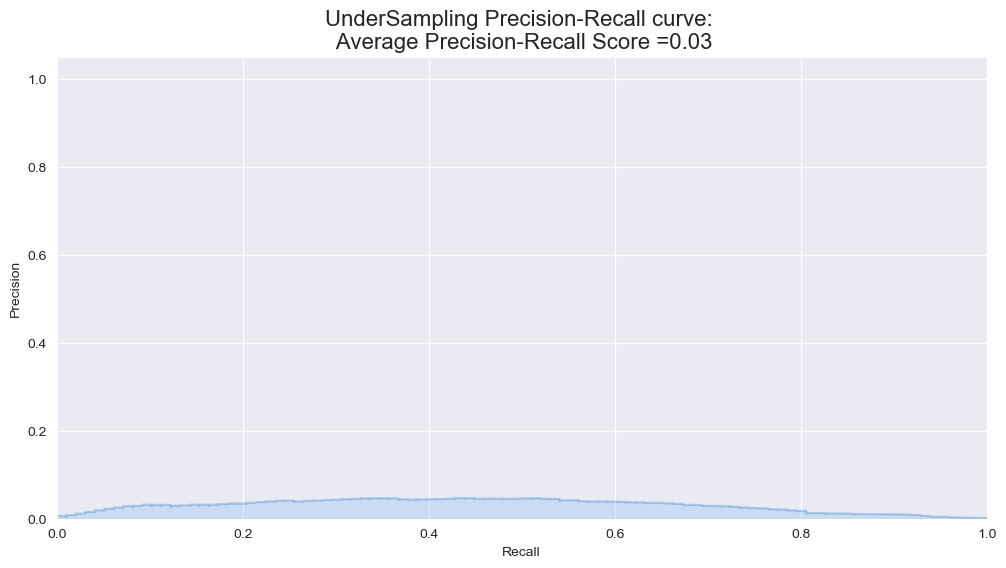

In [43]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(12,6))

precision, recall, _ = precision_recall_curve(original_ytest, undersample_y_score)

plt.step(recall, precision, color='#004a93', alpha=0.2,
         where='post')
plt.fill_between(recall, precision, step='post', alpha=0.2,
                 color='#48a6ff')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.ylim([0.0, 1.05])
plt.xlim([0.0, 1.0])
plt.title('UnderSampling Precision-Recall curve: \n Average Precision-Recall Score ={0:0.2f}'.format(
          undersample_average_precision), fontsize=16)

## SMOTE Technique (Over-Sampling)

![SMOTE Visualization](https://raw.githubusercontent.com/rikunert/SMOTE_visualisation/master/SMOTE_R_visualisation_3.png)

**SMOTE** stands for **Synthetic Minority Over-sampling Technique**. Unlike random under-sampling, SMOTE creates **new synthetic points** to balance the classes, providing an alternative solution to **class imbalance problems**.

---

### Understanding SMOTE

- **Solving Class Imbalance:**
  SMOTE generates synthetic points from the minority class to match the size of the majority class.

- **Location of Synthetic Points:**
  Synthetic points are created along the line segments connecting **closest neighbors** in the minority class.

- **Final Effect:**
  More information is retained compared to under-sampling since no rows are deleted.

- **Accuracy vs. Training Time Tradeoff:**
  SMOTE often leads to higher accuracy than under-sampling but requires more training time because the dataset size increases.

---

### Cross-Validation and Overfitting

A **common mistake** is to perform over- or under-sampling **before cross-validation**. This causes **data leakage**, because the validation folds are influenced by synthetic data from the training folds.

#### The Wrong Way

- Creating synthetic minority points **before cross-validation** gives the model knowledge of the validation set, artificially inflating metrics like precision and recall.
- Example: In 5-fold cross-validation, the training set contains synthetic points that affect the validation fold.

#### The Right Way

- Apply SMOTE **inside the cross-validation pipeline**.
- Synthetic data is generated **only for the training folds** and **does not touch the validation folds**.
- This ensures that evaluation metrics are **realistic** and free of data leakage.

---

### Key Takeaway

Always generate synthetic samples **during cross-validation**. Doing it beforehand leads to **overfitting** and misleading performance metrics.


In [44]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split, RandomizedSearchCV


print('Length of X (train): {} | Length of y (train): {}'.format(len(original_Xtrain), len(original_ytrain)))
print('Length of X (test): {} | Length of y (test): {}'.format(len(original_Xtest), len(original_ytest)))

# List to append the score and then find the average
accuracy_lst = []
precision_lst = []
recall_lst = []
f1_lst = []
auc_lst = []

# Classifier with optimal parameters
# log_reg_sm = grid_log_reg.best_estimator_
log_reg_sm = LogisticRegression()




rand_log_reg = RandomizedSearchCV(LogisticRegression(), log_reg_params, n_iter=4)


# Implementing SMOTE Technique
# Cross Validating the right way
# Parameters
log_reg_params = {"penalty": ['l1', 'l2'], 'C': [0.001, 0.01, 0.1, 1, 10, 100, 1000]}
for train, test in sss.split(original_Xtrain, original_ytrain):
    pipeline = imbalanced_make_pipeline(SMOTE(sampling_strategy='minority'), rand_log_reg) # SMOTE happens during Cross Validation not before..
    model = pipeline.fit(original_Xtrain[train], original_ytrain[train])
    best_est = rand_log_reg.best_estimator_
    prediction = best_est.predict(original_Xtrain[test])

    accuracy_lst.append(pipeline.score(original_Xtrain[test], original_ytrain[test]))
    precision_lst.append(precision_score(original_ytrain[test], prediction))
    recall_lst.append(recall_score(original_ytrain[test], prediction))
    f1_lst.append(f1_score(original_ytrain[test], prediction))
    auc_lst.append(roc_auc_score(original_ytrain[test], prediction))

print('---' * 45)
print('')
print("accuracy: {}".format(np.mean(accuracy_lst)))
print("precision: {}".format(np.mean(precision_lst)))
print("recall: {}".format(np.mean(recall_lst)))
print("f1: {}".format(np.mean(f1_lst)))
print('---' * 45)

Length of X (train): 227846 | Length of y (train): 227846
Length of X (test): 56961 | Length of y (test): 56961
---------------------------------------------------------------------------------------------------------------------------------------

accuracy: 0.941584016730052
precision: 0.05996924052208611
recall: 0.9137293086660175
f1: 0.11080771218982224
---------------------------------------------------------------------------------------------------------------------------------------


In [45]:
labels = ['No Fraud', 'Fraud']
smote_prediction = best_est.predict(original_Xtest)
print(classification_report(original_ytest, smote_prediction, target_names=labels))

              precision    recall  f1-score   support

    No Fraud       1.00      0.99      0.99     56863
       Fraud       0.10      0.86      0.18        98

    accuracy                           0.99     56961
   macro avg       0.55      0.92      0.58     56961
weighted avg       1.00      0.99      0.99     56961



In [46]:
y_score = best_est.decision_function(original_Xtest)

In [47]:
average_precision = average_precision_score(original_ytest, y_score)

print('Average precision-recall score: {0:0.2f}'.format(
      average_precision))

Average precision-recall score: 0.70


Text(0.5, 1.0, 'OverSampling Precision-Recall curve: \n Average Precision-Recall Score =0.70')

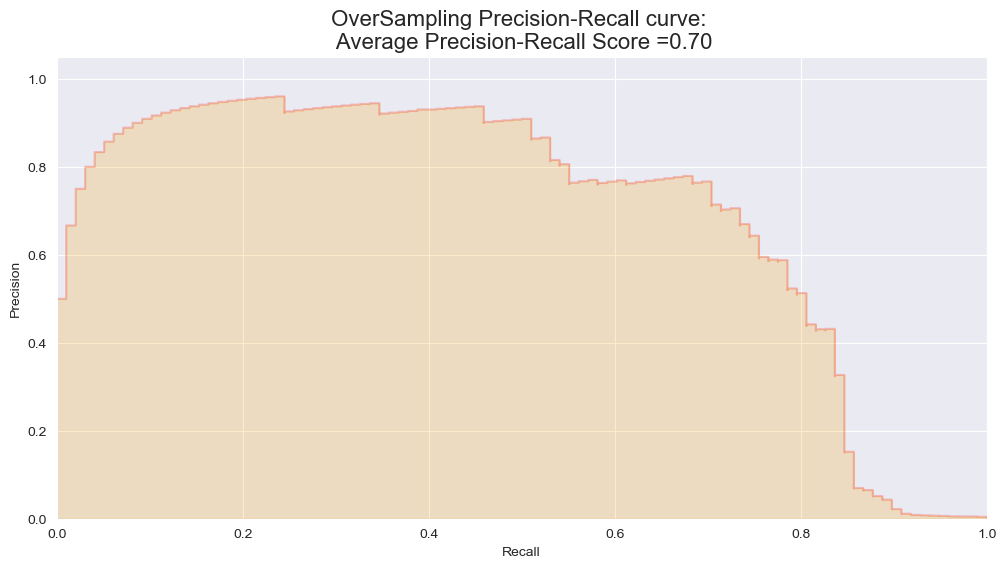

In [48]:
fig = plt.figure(figsize=(12,6))

precision, recall, _ = precision_recall_curve(original_ytest, y_score)

plt.step(recall, precision, color='r', alpha=0.2,
         where='post')
plt.fill_between(recall, precision, step='post', alpha=0.2,
                 color='#F59B00')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.ylim([0.0, 1.05])
plt.xlim([0.0, 1.0])
plt.title('OverSampling Precision-Recall curve: \n Average Precision-Recall Score ={0:0.2f}'.format(
          average_precision), fontsize=16)

In [50]:
from imblearn.over_sampling import SMOTE

# SMOTE Over-Sampling after splitting
sm = SMOTE(sampling_strategy='minority', random_state=42)

# Resample training data
Xsm_train, ysm_train = sm.fit_resample(original_Xtrain, original_ytrain)

In [51]:
# We Improve the score by 2% points approximately
# Implement GridSearchCV and the other models.

# Logistic Regression
t0 = time.time()
log_reg_sm = grid_log_reg.best_estimator_
log_reg_sm.fit(Xsm_train, ysm_train)
t1 = time.time()
print("Fitting oversample data took :{} sec".format(t1 - t0))

Fitting oversample data took :0.9135339260101318 sec


## Test Data with Logistic Regression

### Confusion Matrix

- **Positive/Negative:** Type of class (label) ["No", "Yes"]
- **True/False:** Correctly or incorrectly classified by the model

|                  | Predicted No | Predicted Yes |
|------------------|--------------|---------------|
| **Actual No**    | True Negatives (TN) | False Positives (FP) |
| **Actual Yes**   | False Negatives (FN) | True Positives (TP) |

**Explanation of Squares:**

- **True Negatives (Top-Left):** Correctly classified "No" (No Fraud Detected)
- **False Negatives (Top-Right):** Incorrectly classified "Yes" as "No"
- **False Positives (Bottom-Left):** Incorrectly classified "No" as "Yes"
- **True Positives (Bottom-Right):** Correctly classified "Yes" (Fraud Detected)

---

### Summary

- **Random Under-Sampling:** Final performance is evaluated on the undersampled subset, **not** the original dataset.
- **Best Models:** Logistic Regression and Support Vector Classifier (SVM) performed the best for fraud detection in this subset.


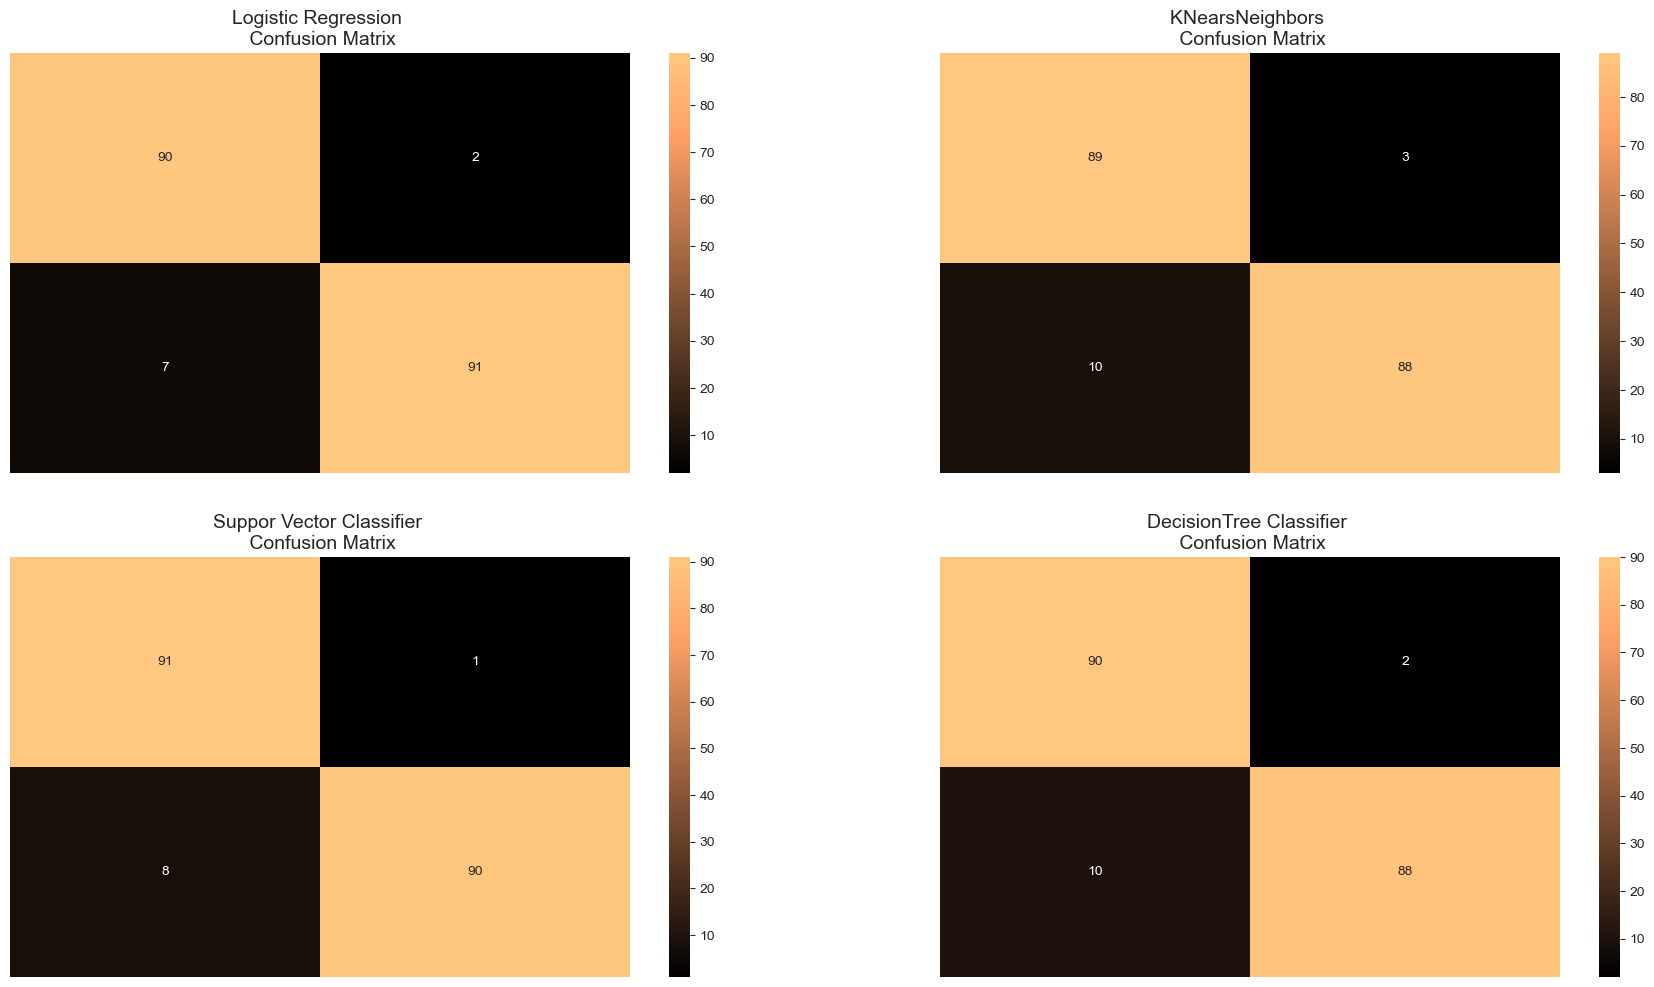

In [52]:
from sklearn.metrics import confusion_matrix

# Logistic Regression fitted using SMOTE technique
y_pred_log_reg = log_reg_sm.predict(X_test)

# Other models fitted with UnderSampling
y_pred_knear = knears_neighbors.predict(X_test)
y_pred_svc = svc.predict(X_test)
y_pred_tree = tree_clf.predict(X_test)


log_reg_cf = confusion_matrix(y_test, y_pred_log_reg)
kneighbors_cf = confusion_matrix(y_test, y_pred_knear)
svc_cf = confusion_matrix(y_test, y_pred_svc)
tree_cf = confusion_matrix(y_test, y_pred_tree)

fig, ax = plt.subplots(2, 2,figsize=(22,12))


sns.heatmap(log_reg_cf, ax=ax[0][0], annot=True, cmap=plt.cm.copper)
ax[0, 0].set_title("Logistic Regression \n Confusion Matrix", fontsize=14)
ax[0, 0].set_xticklabels(['', ''], fontsize=14, rotation=90)
ax[0, 0].set_yticklabels(['', ''], fontsize=14, rotation=360)

sns.heatmap(kneighbors_cf, ax=ax[0][1], annot=True, cmap=plt.cm.copper)
ax[0][1].set_title("KNearsNeighbors \n Confusion Matrix", fontsize=14)
ax[0][1].set_xticklabels(['', ''], fontsize=14, rotation=90)
ax[0][1].set_yticklabels(['', ''], fontsize=14, rotation=360)

sns.heatmap(svc_cf, ax=ax[1][0], annot=True, cmap=plt.cm.copper)
ax[1][0].set_title("Suppor Vector Classifier \n Confusion Matrix", fontsize=14)
ax[1][0].set_xticklabels(['', ''], fontsize=14, rotation=90)
ax[1][0].set_yticklabels(['', ''], fontsize=14, rotation=360)

sns.heatmap(tree_cf, ax=ax[1][1], annot=True, cmap=plt.cm.copper)
ax[1][1].set_title("DecisionTree Classifier \n Confusion Matrix", fontsize=14)
ax[1][1].set_xticklabels(['', ''], fontsize=14, rotation=90)
ax[1][1].set_yticklabels(['', ''], fontsize=14, rotation=360)


plt.show()

In [53]:
from sklearn.metrics import classification_report


print('Logistic Regression:')
print(classification_report(y_test, y_pred_log_reg))

print('KNears Neighbors:')
print(classification_report(y_test, y_pred_knear))

print('Support Vector Classifier:')
print(classification_report(y_test, y_pred_svc))

print('Support Vector Classifier:')
print(classification_report(y_test, y_pred_tree))

Logistic Regression:
              precision    recall  f1-score   support

           0       0.93      0.98      0.95        92
           1       0.98      0.93      0.95        98

    accuracy                           0.95       190
   macro avg       0.95      0.95      0.95       190
weighted avg       0.95      0.95      0.95       190

KNears Neighbors:
              precision    recall  f1-score   support

           0       0.90      0.97      0.93        92
           1       0.97      0.90      0.93        98

    accuracy                           0.93       190
   macro avg       0.93      0.93      0.93       190
weighted avg       0.93      0.93      0.93       190

Support Vector Classifier:
              precision    recall  f1-score   support

           0       0.92      0.99      0.95        92
           1       0.99      0.92      0.95        98

    accuracy                           0.95       190
   macro avg       0.95      0.95      0.95       190
weighted

In [54]:
# Final Score in the test set of logistic regression
from sklearn.metrics import accuracy_score

# Logistic Regression with Under-Sampling
y_pred = log_reg.predict(X_test)
undersample_score = accuracy_score(y_test, y_pred)



# Logistic Regression with SMOTE Technique (Better accuracy with SMOTE t)
y_pred_sm = best_est.predict(original_Xtest)
oversample_score = accuracy_score(original_ytest, y_pred_sm)


d = {'Technique': ['Random UnderSampling', 'Oversampling (SMOTE)'], 'Score': [undersample_score, oversample_score]}
final_df = pd.DataFrame(data=d)

# Move column
score = final_df['Score']
final_df.drop('Score', axis=1, inplace=True)
final_df.insert(1, 'Score', score)

# Note how high is accuracy score it can be misleading!
final_df

,Technique,Score
0,Random UnderSampling,0.952632
1,Oversampling (SMOTE),0.986148


## Neural Networks Testing: Random Under-Sampling vs Over-Sampling (SMOTE)

In this section, we implement a **simple Neural Network** with one hidden layer to compare the performance of models trained on **random undersampled data** versus **oversampled data (SMOTE)** for fraud detection.

---

### Main Goal

- Explore how a simple neural network behaves on both undersampled and oversampled datasets.
- Evaluate the network’s ability to predict **both non-fraud and fraud transactions**.
- **Why both classes matter:** Correctly identifying non-fraud transactions prevents unnecessary blocking of legitimate purchases, which is critical in financial applications.

---

### Confusion Matrix

|                  | Predicted No | Predicted Yes |
|------------------|--------------|---------------|
| **Actual No**    | True Negatives (TN) | False Positives (FP) |
| **Actual Yes**   | False Negatives (FN) | True Positives (TP) |

**Explanation of Squares:**

- **Upper Left:** Correctly classified non-fraud transactions
- **Upper Right:** Non-fraud transactions incorrectly classified as fraud
- **Lower Left:** Fraud transactions incorrectly classified as non-fraud
- **Lower Right:** Correctly classified fraud transactions

---

### Summary (Keras | Random Under-Sampling)

- **Dataset:** Model is trained on both **undersampled** and **oversampled (SMOTE)** datasets and tested on the **original testing set**.

- **Neural Network Structure:**
  - Input layer: number of nodes = number of features + bias node
  - Hidden layer: 32 nodes
  - Output layer: 2 nodes (0 = No Fraud, 1 = Fraud)

- **Other characteristics:**
  - Learning rate: 0.001
  - Optimizer: Adam
  - Hidden activation function: ReLU
  - Output activation: softmax with **sparse categorical cross-entropy**
    - Predicts probabilities for "No Fraud" vs "Fraud"
    - Final prediction selects the class with **highest probability**


In [55]:
import keras
from keras import backend as K
from keras.models import Sequential
from keras.layers import Activation
from keras.layers.core import Dense
from keras.optimizers import Adam
from keras.metrics import categorical_crossentropy

n_inputs = X_train.shape[1]

undersample_model = Sequential([
    Dense(n_inputs, input_shape=(n_inputs, ), activation='relu'),
    Dense(32, activation='relu'),
    Dense(2, activation='softmax')
])

In [56]:
undersample_model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 30)                930       
                                                                 
 dense_1 (Dense)             (None, 32)                992       
                                                                 
 dense_2 (Dense)             (None, 2)                 66        
                                                                 
Total params: 1,988
Trainable params: 1,988
Non-trainable params: 0
_________________________________________________________________


In [57]:
undersample_model.compile(Adam(lr=0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [58]:
undersample_model.fit(X_train, y_train, validation_split=0.2, batch_size=25, epochs=20, shuffle=True, verbose=2)

Epoch 1/20
25/25 - 164s - loss: 0.4434 - accuracy: 0.8212 - val_loss: 0.3402 - val_accuracy: 0.9145 - 164s/epoch - 7s/step
Epoch 2/20
25/25 - 0s - loss: 0.3062 - accuracy: 0.9056 - val_loss: 0.2671 - val_accuracy: 0.9342 - 67ms/epoch - 3ms/step
Epoch 3/20
25/25 - 0s - loss: 0.2429 - accuracy: 0.9139 - val_loss: 0.2224 - val_accuracy: 0.9408 - 58ms/epoch - 2ms/step
Epoch 4/20
25/25 - 0s - loss: 0.2047 - accuracy: 0.9205 - val_loss: 0.1920 - val_accuracy: 0.9474 - 60ms/epoch - 2ms/step
Epoch 5/20
25/25 - 0s - loss: 0.1801 - accuracy: 0.9272 - val_loss: 0.1800 - val_accuracy: 0.9539 - 61ms/epoch - 2ms/step
Epoch 6/20
25/25 - 0s - loss: 0.1636 - accuracy: 0.9321 - val_loss: 0.1666 - val_accuracy: 0.9539 - 64ms/epoch - 3ms/step
Epoch 7/20
25/25 - 0s - loss: 0.1503 - accuracy: 0.9354 - val_loss: 0.1598 - val_accuracy: 0.9539 - 53ms/epoch - 2ms/step
Epoch 8/20
25/25 - 0s - loss: 0.1418 - accuracy: 0.9371 - val_loss: 0.1576 - val_accuracy: 0.9539 - 54ms/epoch - 2ms/step
Epoch 9/20
25/25 - 0s -

In [59]:
undersample_predictions = undersample_model.predict(original_Xtest, batch_size=200, verbose=0)

In [61]:
y_probs = undersample_model.predict(original_Xtest, batch_size=200, verbose=0)
undersample_fraud_predictions = y_probs.argmax(axis=1)

In [86]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Create a confusion matrix
def plot_confusion_matrix(y_true, y_pred, labels, title, ax):
    cm = confusion_matrix(y_true, y_pred)

    # Plot with seaborn
    sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
                xticklabels=labels, yticklabels=labels,
                cbar=False, square=True, ax=ax)

    ax.set_title(title, fontsize=14)
    ax.set_ylabel('True label')
    ax.set_xlabel('Predicted label')

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

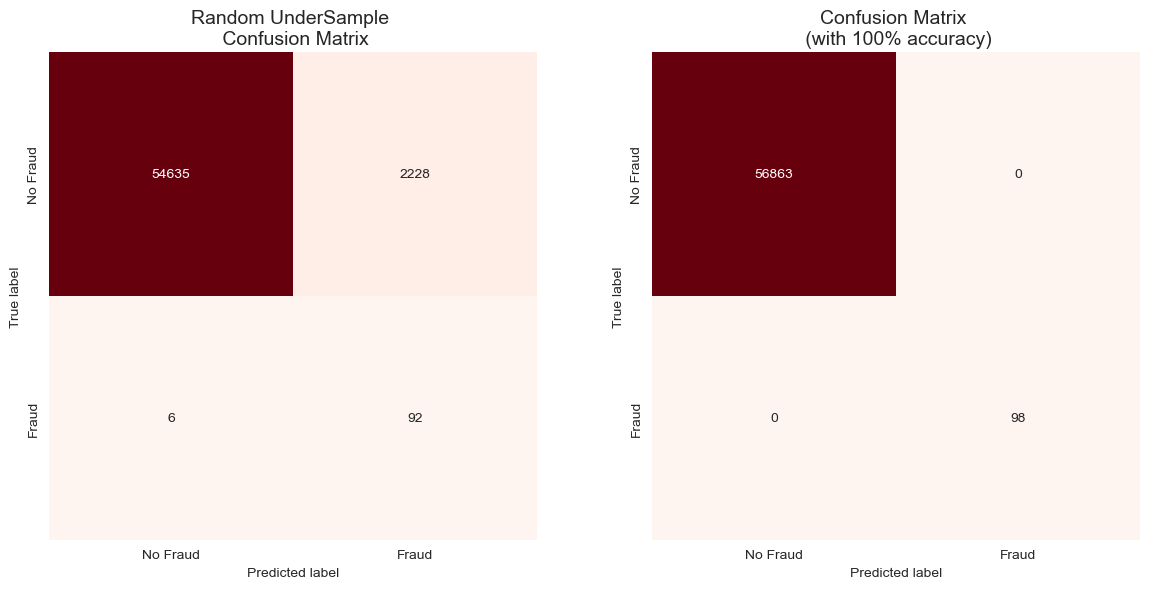

In [87]:
undersample_cm = confusion_matrix(original_ytest, undersample_fraud_predictions)
actual_cm = confusion_matrix(original_ytest, original_ytest)
labels = ['No Fraud', 'Fraud']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

plot_confusion_matrix(original_ytest, undersample_fraud_predictions,
                             labels,
                             "Random UnderSample \n Confusion Matrix",
                             axes[0])

plot_confusion_matrix(original_ytest, original_ytest,
                             labels,
                             "Confusion Matrix \n (with 100% accuracy)",
                             axes[1])

plt.tight_layout()
plt.show()

## Keras || OverSampling (SMOTE):

In [88]:
n_inputs = Xsm_train.shape[1]

oversample_model = Sequential([
    Dense(n_inputs, input_shape=(n_inputs, ), activation='relu'),
    Dense(32, activation='relu'),
    Dense(2, activation='softmax')
])

In [89]:
oversample_model.compile(Adam(lr=0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [90]:
oversample_model.fit(Xsm_train, ysm_train, validation_split=0.2, batch_size=300, epochs=20, shuffle=True, verbose=2)

Epoch 1/20
1214/1214 - 2s - loss: 0.0696 - accuracy: 0.9773 - val_loss: 0.0234 - val_accuracy: 0.9927 - 2s/epoch - 2ms/step
Epoch 2/20
1214/1214 - 2s - loss: 0.0152 - accuracy: 0.9961 - val_loss: 0.0102 - val_accuracy: 0.9990 - 2s/epoch - 2ms/step
Epoch 3/20
1214/1214 - 2s - loss: 0.0082 - accuracy: 0.9983 - val_loss: 0.0048 - val_accuracy: 0.9999 - 2s/epoch - 2ms/step
Epoch 4/20
1214/1214 - 2s - loss: 0.0054 - accuracy: 0.9989 - val_loss: 0.0042 - val_accuracy: 0.9999 - 2s/epoch - 2ms/step
Epoch 5/20
1214/1214 - 2s - loss: 0.0041 - accuracy: 0.9991 - val_loss: 0.0041 - val_accuracy: 0.9990 - 2s/epoch - 2ms/step
Epoch 6/20
1214/1214 - 2s - loss: 0.0034 - accuracy: 0.9993 - val_loss: 0.0013 - val_accuracy: 0.9997 - 2s/epoch - 2ms/step
Epoch 7/20
1214/1214 - 2s - loss: 0.0027 - accuracy: 0.9995 - val_loss: 0.0024 - val_accuracy: 0.9999 - 2s/epoch - 2ms/step
Epoch 8/20
1214/1214 - 2s - loss: 0.0022 - accuracy: 0.9996 - val_loss: 0.0017 - val_accuracy: 0.9998 - 2s/epoch - 2ms/step
Epoch 9/

In [91]:
oversample_predictions = oversample_model.predict(original_Xtest, batch_size=200, verbose=0)

In [92]:
y_probs = oversample_model.predict(original_Xtest, batch_size=200, verbose=0)
oversample_fraud_predictions = y_probs.argmax(axis=1)

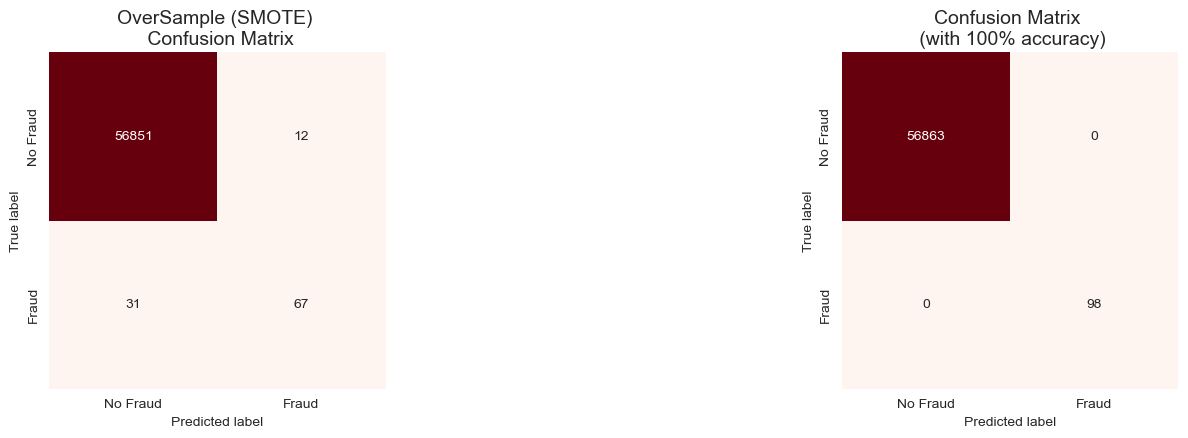

In [97]:
oversample_smote = confusion_matrix(original_ytest, oversample_fraud_predictions)
actual_cm = confusion_matrix(original_ytest, original_ytest)
labels = ['No Fraud', 'Fraud']

fig = plt.figure(figsize=(16, 8))

ax1 = fig.add_subplot(221)
plot_confusion_matrix(original_ytest, oversample_fraud_predictions, labels,
                      title="OverSample (SMOTE) \n Confusion Matrix", ax=ax1)

ax2 = fig.add_subplot(222)
plot_confusion_matrix(original_ytest, original_ytest, labels,
                      title="Confusion Matrix \n (with 100% accuracy)", ax=ax2)

plt.tight_layout()
plt.show()

## Conclusion

- **Impact of SMOTE:** Implementing SMOTE on our imbalanced dataset helped balance the labels (more non-fraud than fraud transactions).

- **Observations:**
  - Sometimes, the neural network trained on the **oversampled dataset** predicts **fewer correct fraud transactions** than the model trained on the undersampled dataset.
  - The **removal of outliers** was applied only on the **random undersample dataset**, not on the oversampled one.
  - In the undersample data, the model often **misclassifies non-fraud transactions as fraud**, which could lead to:
    - Blocking legitimate purchases
    - Increased customer complaints and dissatisfaction

- **Next Steps:**
  - Apply **outlier removal** to the oversampled dataset to see if test set accuracy improves.

- **Note:**
  - Predictions and accuracies may vary due to **data shuffling** in both types of datasets.
  - The main goal is to ensure the models correctly classify **both fraud and non-fraud transactions**.
  - Further updates will follow as we refine the models.


In [100]:
from sklearn.metrics import classification_report
import numpy as np

# Get predictions from your oversample model
y_probs = oversample_model.predict(original_Xtest, batch_size=200, verbose=0)
oversample_fraud_predictions = y_probs.argmax(axis=1)

# Classification report for SMOTE model predictions
print("=" * 60)
print("CLASSIFICATION REPORT - OVERSAMPLE (SMOTE) MODEL")
print("=" * 60)
smote_report = classification_report(original_ytest, oversample_fraud_predictions,
                                     target_names=['No Fraud', 'Fraud'])
print(smote_report)

# Classification report for perfect predictions (actual vs actual)
print("\n" + "=" * 60)
print("CLASSIFICATION REPORT - PERFECT PREDICTIONS (100% Accuracy)")
print("=" * 60)
perfect_report = classification_report(original_ytest, original_ytest,
                                       target_names=['No Fraud', 'Fraud'])
print(perfect_report)

# Optional: Get the classification report as a dictionary for further analysis
smote_report_dict = classification_report(original_ytest, oversample_fraud_predictions,
                                          target_names=['No Fraud', 'Fraud'], output_dict=True)

# Print specific metrics if needed
print("=" * 60)
print("KEY METRICS SUMMARY")
print("=" * 60)
print(f"SMOTE Model - Overall Accuracy: {smote_report_dict['accuracy']:.4f}")
print(f"SMOTE Model - Fraud Precision: {smote_report_dict['Fraud']['precision']:.4f}")
print(f"SMOTE Model - Fraud Recall: {smote_report_dict['Fraud']['recall']:.4f}")
print(f"SMOTE Model - Fraud F1-Score: {smote_report_dict['Fraud']['f1-score']:.4f}")

CLASSIFICATION REPORT - OVERSAMPLE (SMOTE) MODEL
              precision    recall  f1-score   support

    No Fraud       1.00      1.00      1.00     56863
       Fraud       0.85      0.68      0.76        98

    accuracy                           1.00     56961
   macro avg       0.92      0.84      0.88     56961
weighted avg       1.00      1.00      1.00     56961


CLASSIFICATION REPORT - PERFECT PREDICTIONS (100% Accuracy)
              precision    recall  f1-score   support

    No Fraud       1.00      1.00      1.00     56863
       Fraud       1.00      1.00      1.00        98

    accuracy                           1.00     56961
   macro avg       1.00      1.00      1.00     56961
weighted avg       1.00      1.00      1.00     56961

KEY METRICS SUMMARY
SMOTE Model - Overall Accuracy: 0.9992
SMOTE Model - Fraud Precision: 0.8481
SMOTE Model - Fraud Recall: 0.6837
SMOTE Model - Fraud F1-Score: 0.7571
